# Protein sequence alignment networks: collections, graph rules, and label recovery

## Research question

> How do graphs built from different protein collections, alignment methods,
> and graph-construction rules compare?

A sequence-similarity network (SSN) is a weighted undirected graph
$G=(V,E,w)$: $V$ contains sequences, $E$ contains selected sequence pairs, and
$w:E\to\mathbb R$ assigns similarity. Nodes here represent Pfam domain
instances. SSNs support protein-family exploration
([Atkinson et al., 2009](https://doi.org/10.1371/journal.pone.0004345);
[Gerlt et al., 2015](https://doi.org/10.1016/j.bbapap.2015.04.015)).
Phylogenetic inference requires separate evolutionary models.

```text
domain collection
    -> method-specific pair scores
    -> graph rule
    -> weighted graph
    -> unsupervised communities
    -> agreement with withheld Pfam labels
```

## Biological terms

- **Protein domain:** sequence region treated as a structural, functional, or
  evolutionary unit. One protein may contain several domains. Each node here
  is one ungapped Pfam seed-domain instance.
- **Pfam family:** homologous domains represented by a curated seed alignment
  and profile hidden Markov model.
- **Pfam clan:** families linked by evidence of common ancestry
  ([Mistry et al., 2021](https://doi.org/10.1093/nar/gkaa913)). Family and clan
  provide fine and coarse reference labels.
- **Exact local alignment score:** maximum score over matching subsequences
  under a substitution matrix and affine gap costs. Biopython uses Smith--Waterman
  ([Smith and Waterman, 1981](https://doi.org/10.1016/0022-2836(81)90087-5)),
  Gotoh affine gaps
  ([Gotoh, 1982](https://doi.org/10.1016/0022-2836(82)90398-9)), and BLOSUM62
  substitutions
  ([Henikoff and Henikoff, 1992](https://doi.org/10.1073/pnas.89.22.10915)).
- **Community:** vertex block returned by weighted Louvain modularity
  optimisation at resolution $1$
  ([Blondel et al., 2008](https://doi.org/10.1088/1742-5468/2008/10/P10008)).
  NetworkX supplies implementation
  ([Hagberg et al., 2008](https://proceedings.scipy.org/articles/PFVC8793.pdf)).

## Graph notation and rules

For vertex set $V$ with $\lvert V\rvert=n$, define possible pairs
$\mathcal P(V)=\{\{i,j\}:i,j\in V,\ i\neq j\}$ and
$P=\lvert\mathcal P(V)\rvert=\binom n2$. Method $m$ reports available set
$A_m\subseteq\mathcal P(V)$ and score $s_e^m$ for $e\in A_m$. A rule selects
$E\subseteq A_m$; realised density is $\delta=\lvert E\rvert/P$.

For $i\in V$, let $A_m(i)=\{j\in V:\{i,j\}\in A_m\}$ be its available
neighbours. $N_k^m(i)$ contains first
$\min(k,\lvert A_m(i)\rvert)$ neighbours after descending score and identifier
tie-break. For $e\in A_m$, let $r_e^m$ be ascending average-tie rank divided by
$\lvert A_m\rvert$, and let $q_e^m$ be 1-based position after descending score
and identifier tie-break. Define
$b_m(d)=\min(\lvert A_m\rvert,\lceil dP\rceil)$. Three rules select:

1. **`top_k`**, $k\in\mathbb N_0$:

   $$E_{m,k}^{\mathrm{top}}=\{e=\{i,j\}\in A_m:
   j\in N_k^m(i)\ \text{or}\ i\in N_k^m(j)\}.$$

2. **`percentile`**, $p\in[0,1]$:

   $$E_{m,p}^{\mathrm{pct}}=\{e\in A_m:r_e^m\geq p\}.$$

3. **`target_density`**, $d\in[0,1]$:

   $$E_{m,d}^{\mathrm{dens}}=\{e\in A_m:q_e^m\leq b_m(d)\}.$$

`top_k` gives data-dependent density because reciprocal nominations collapse
to one edge. `percentile` ranks $A_m$, so unequal coverage changes
realised density. With $A_m=\mathcal P(V)$ and no boundary ties, percentile
$p$ approximates density $1-p$. `target_density` supplies matched edge budgets;
shortfall equals $\max(0,\lceil dP\rceil-\lvert A_m\rvert)$.
Threshold sweeps and task-specific validation follow SSN practice
([Apeltsin et al., 2011](https://doi.org/10.1093/bioinformatics/btq655);
[Hornung and Terrapon, 2023](https://doi.org/10.1371/journal.pcbi.1010881)).

## Agreement measures

Choose one of $n=\lvert V\rvert$ vertices uniformly. Let $U$ be its detected
community and $V^*$ its withheld Pfam label. For community $u$ and label $v$,
let $n_{uv}$ count vertices with both values. Define row and column counts
$n_u=\sum_v n_{uv}$ and $n_v=\sum_u n_{uv}$. Then

$$
p_{uv}=\Pr(U=u,V^*=v)=\frac{n_{uv}}{n},\qquad
p_u=\Pr(U=u)=\frac{n_u}{n}=\sum_v p_{uv},\qquad
p_v=\Pr(V^*=v)=\frac{n_v}{n}=\sum_u p_{uv}.
$$

$p_{uv}$ is joint vertex proportion; $p_u$ and $p_v$ are community and Pfam-label
marginal proportions. Entropies and mutual information are

$$
H(U)=-\sum_u p_u\log p_u,\qquad
H(V^*)=-\sum_v p_v\log p_v,\qquad
I(U;V^*)=\sum_{u,v}p_{uv}\log\frac{p_{uv}}{p_up_v}.
$$

Sums cover observed community and label values; $0\log0$ terms equal zero.

Arithmetic-normalised mutual information and adjusted mutual information are

$$
\operatorname{NMI}=\frac{I(U;V^*)}{[H(U)+H(V^*)]/2},\qquad
\operatorname{AMI}=\frac{I(U;V^*)-\mathbb E[I(U;V^*)]}
{[H(U)+H(V^*)]/2-\mathbb E[I(U;V^*)]}.
$$

$\mathbb E[I]$ averages mutual information over random contingency tables
with observed community and Pfam-label block sizes fixed. AMI
controls chance agreement from varying community counts; NMI supplies a bounded
descriptive measure
([Vinh et al., 2010](https://www.jmlr.org/papers/v11/vinh10a.html);
[Pedregosa et al., 2011](https://www.jmlr.org/papers/v12/pedregosa11a.html)).

## Score methods and structure

Biopython supplies exact local alignment
([Cock et al., 2009](https://doi.org/10.1093/bioinformatics/btp163)). Local
NCBI BLAST+ supplies heuristic search
([Camacho et al., 2009](https://doi.org/10.1186/1471-2105-10-421)). BLAST graph
weight is bit score $S'=(\lambda S-\ln K)/\ln2$, where $S$ is raw score and
$\lambda,K$ depend on scoring system and residue frequencies
([Karlin and Altschul, 1990](https://doi.org/10.1073/pnas.87.6.2264);
[Altschul et al., 1990](https://doi.org/10.1016/S0022-2836(05)80360-2)).
Notebook 02 demonstrates pretrained DEDAL
([Llinares-López et al., 2023](https://doi.org/10.1038/s41592-022-01700-2));
recorded runtime excludes it from scaled all-pairs experiment.

Part A develops workflow on a controlled panel. Part B evaluates repeated
samples. Cells load empirical values from stored artifacts. Reusable modules
under `src/protein_alignment_networks/` implement sampling, scoring, graph
construction, evaluation, and visualisation; `scripts/` records runs.


## Questions examined

Part A:

1. How do collection size and composition change topology?
2. How do isolates, components, density, and biological edge composition vary
   across rules?
3. How strongly do Biopython and BLAST scores and edges agree?

Part B:

4. What family- and clan-recovery distributions arise across repeated samples?
5. How do `top_k`, percentile, and target-density rules compare?
6. How large are composition, rule, and method effects?
7. Which composition cells contain distinct replicate node sets?


In [1]:
import json
import subprocess
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Image, display

from protein_alignment_networks import (
    build_similarity_graph,
    graph_summary,
    read_fasta,
    save_graph_bundle,
)
from protein_alignment_networks.visualization import (
    draw_similarity_graph,
    shared_graph_layout,
)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

# Part A — controlled-panel development

Convenience panel contains two specified families from each of three Pfam
clans: globin, kinase, and SH3, exposing same-family, within-clan, and
between-clan relationships during workflow development. Manual family choice
limits inference to mechanism and software checks. A2 calculates realised
domain and pair counts from metadata.


## A1. Configure controlled panel

Each family contributes every eligible curated seed sequence up to 40;
larger families contribute 40 diversity-selected representatives. Defaults
reuse saved downloads and scores. Set `RUN_DATA_PREPARATION` or
`RUN_SCORING` to `True` to rebuild corresponding artifacts.


In [2]:
RUN_DATA_PREPARATION = False
RUN_SCORING = False
METHODS_TO_RUN = ('biopython', 'blast')  # add 'dedal' only intentionally
BLAST_THREADS = 4

BALANCED_COLLECTION_SIZES = (60, 120, 180)
GRAPH_RULES = {
    'top_k': (1, 2, 5, 10),
    'percentile': (0.90, 0.95, 0.98, 0.99),
}
VISUAL_RULE = 'top_k'
VISUAL_THRESHOLD = 5
RANDOM_SEED = 42

DATASET_DIRECTORY = PROJECT_ROOT / 'data/processed/pfam_clan_panel'
FASTA_PATH = DATASET_DIRECTORY / 'pfam_clan_panel.fasta'
METADATA_PATH = DATASET_DIRECTORY / 'pfam_clan_panel_metadata.tsv'
DATASET_MANIFEST_PATH = DATASET_DIRECTORY / 'pfam_clan_panel_manifest.json'
SCORE_DIRECTORY = PROJECT_ROOT / 'outputs/tables/pfam_clan_panel'
FIGURE_DIRECTORY = PROJECT_ROOT / 'outputs/figures/pfam_clan_panel'
GRAPH_DIRECTORY = PROJECT_ROOT / 'outputs/graphs/pfam_clan_panel'
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
GRAPH_DIRECTORY.mkdir(parents=True, exist_ok=True)

## A2. Prepare controlled master collection

Family accessions were chosen manually:
PF00042 and PF01152 from CL0090; PF00069 and PF07714 from CL0016; PF00018 and
PF08239 from CL0010. `DEFAULT_FAMILIES` in
`scripts/prepare_pfam_clan_panel.py` records this list.

Domain selection is deterministic:

1. Download official curated seed alignment through InterPro.
2. Extract annotated domains; reject invalid, mismatched, and duplicate
   ungapped sequences.
3. Retain all eligible domains below configured cap.
4. Above cap, apply farthest-point sampling to seed-alignment identity. Start
   with sequence nearest median ungapped length; resolve ties by recorded ID.
5. Remove alignment gaps before independent scoring.

Selection favours sequence diversity. Cell regenerates or loads data, verifies
FASTA against metadata, and reads realised counts from manifest and metadata.


In [3]:
if RUN_DATA_PREPARATION:
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / 'scripts/prepare_pfam_clan_panel.py')],
        cwd=PROJECT_ROOT,
        check=True,
    )

metadata = pd.read_csv(METADATA_PATH, sep='\t')
dataset_manifest = json.loads(DATASET_MANIFEST_PATH.read_text())
sequences = read_fasta(FASTA_PATH)
assert set(sequences) == set(metadata['node_id'])
print(
    f"{len(metadata)} protein domains; "
    f"{dataset_manifest['unique_pair_count']:,} unique pairs; "
    f"{metadata['family_accession'].nunique()} families; "
    f"{metadata['clan_accession'].nunique()} clans"
)
display(
    metadata.groupby(
        ['clan_accession', 'clan_name', 'family_accession', 'family_name'],
        dropna=False,
    )
    .agg(proteins=('node_id', 'size'), median_length=('domain_length', 'median'))
    .reset_index()
)

205 protein domains; 20,910 unique pairs; 6 families; 3 clans


,clan_accession,clan_name,family_accession,family_name,proteins,median_length
0,CL0010,SH3,PF00018,SH3 domain,40,47.0
1,CL0010,SH3,PF08239,Bacterial SH3 domain,40,56.0
2,CL0016,PKinase,PF00069,Protein kinase domain,37,263.0
3,CL0016,PKinase,PF07714,Protein tyrosine and serine/threonine kinase,40,261.5
4,CL0090,Globin,PF00042,Globin,40,114.0
5,CL0090,Globin,PF01152,Bacterial-like globin,8,119.5


## A3. Produce or reuse pair scores

`scripts/run_pair_scores.py` writes canonical pair table and run manifest.
Manifest records runtimes, versions, parameters, and checksums. Controlled
analysis reuses Biopython and BLAST scores. DEDAL remains available through
Notebook 02.


In [4]:
if RUN_SCORING:
    subprocess.run(
        [
            sys.executable,
            str(PROJECT_ROOT / 'scripts/run_pair_scores.py'),
            '--fasta', str(FASTA_PATH),
            '--dataset-manifest', str(DATASET_MANIFEST_PATH),
            '--output-directory', str(SCORE_DIRECTORY),
            '--experiment-name', 'Pfam clan panel exploration',
            '--methods', *METHODS_TO_RUN,
            '--threads', str(BLAST_THREADS),
        ],
        cwd=PROJECT_ROOT,
        check=True,
    )

pair_scores = pd.read_csv(SCORE_DIRECTORY / 'paired_scores.tsv', sep='\t')
score_manifest = json.loads((SCORE_DIRECTORY / 'run_manifest.json').read_text())
METHOD_COLUMNS = {
    method: column
    for method, column in {
        'biopython': 'biopython_score',
        'blast': 'blast_bit_score',
        'dedal': 'dedal_sw_score',
    }.items()
    if column in pair_scores
}
print('Completed methods:', ', '.join(METHOD_COLUMNS))
print('Recorded runtimes (seconds):', score_manifest['runtimes_seconds'])
assert len(pair_scores) == dataset_manifest['unique_pair_count']

Completed methods: biopython, blast
Recorded runtimes (seconds): {'biopython': 3.4061960830003954, 'blast': 5.591043374995934}


## A4. Label pair relationships

Each pair receives one reference class: same family, different families within
one clan, or different clans. Alignment methods receive sequences only.


In [5]:
node_metadata = metadata.set_index('node_id')
pair_analysis = pair_scores.copy()
for endpoint in ('a', 'b'):
    pair_analysis[f'family_{endpoint}'] = pair_analysis[f'protein_{endpoint}'].map(
        node_metadata['family_accession']
    )
    pair_analysis[f'clan_{endpoint}'] = pair_analysis[f'protein_{endpoint}'].map(
        node_metadata['clan_accession']
    )
    pair_analysis[f'length_{endpoint}'] = pair_analysis[f'protein_{endpoint}'].map(
        node_metadata['domain_length']
    )
pair_analysis['relationship'] = np.select(
    [
        pair_analysis['family_a'] == pair_analysis['family_b'],
        pair_analysis['clan_a'] == pair_analysis['clan_b'],
    ],
    ['same family', 'same clan, different family'],
    default='different clan',
)
RELATIONSHIP_ORDER = [
    'same family', 'same clan, different family', 'different clan'
]
display(
    pair_analysis.groupby('relationship', observed=True)
    .agg(pairs=('protein_a', 'size'), blast_reported=('blast_bit_score', 'count'))
    .reindex(RELATIONSHIP_ORDER)
)

,pairs,blast_reported
relationship,,
same family,3814,2521
"same clan, different family",3400,1612
different clan,13696,465


## A5. Examine scores, coverage, and reference classes

Method-native scores have different units. Within-method plots assess
separation among reference classes; coverage table counts reported scores.
Cell saves `outputs/figures/pfam_clan_panel/scores_by_relationship.png` from
`outputs/tables/pfam_clan_panel/paired_scores.tsv` joined with node metadata.


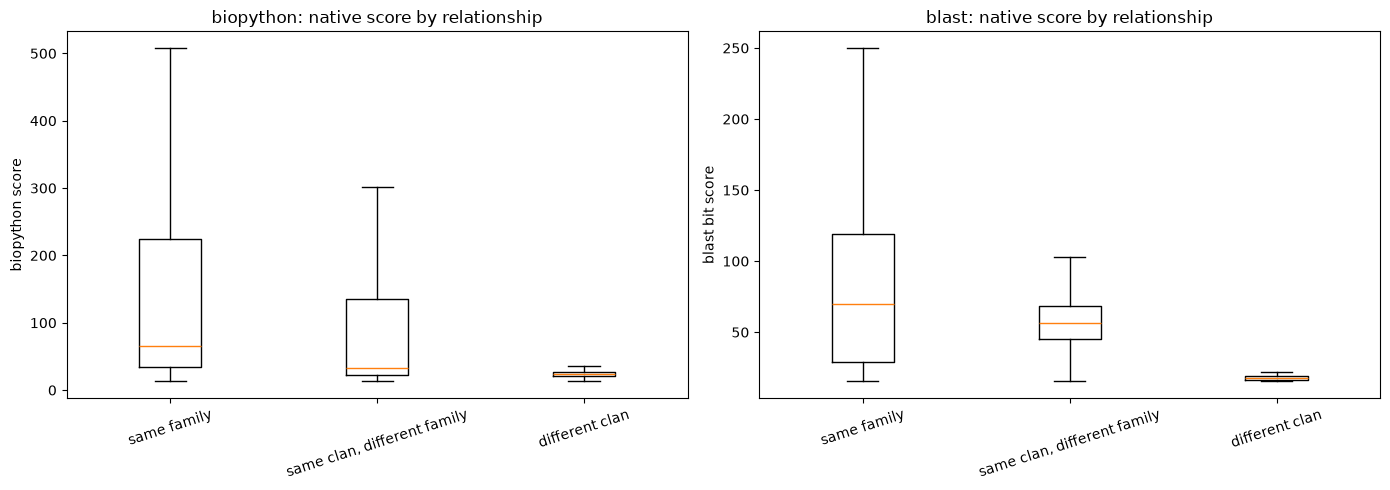

,relationship,method,pairs,reported_pairs,coverage_fraction
0,same family,biopython,3814,3814,1.000000
1,same family,blast,3814,2521,0.660986
2,"same clan, different family",biopython,3400,3400,1.000000
3,"same clan, different family",blast,3400,1612,0.474118
4,different clan,biopython,13696,13696,1.000000
5,different clan,blast,13696,465,0.033952


In [6]:
figure, axes = plt.subplots(1, len(METHOD_COLUMNS), figsize=(7 * len(METHOD_COLUMNS), 5))
axes = np.atleast_1d(axes)
for axis, (method, column) in zip(axes, METHOD_COLUMNS.items(), strict=True):
    values = [
        pair_analysis.loc[pair_analysis['relationship'] == label, column].dropna()
        for label in RELATIONSHIP_ORDER
    ]
    axis.boxplot(values, tick_labels=RELATIONSHIP_ORDER, showfliers=False)
    axis.set_title(f'{method}: native score by relationship')
    axis.set_ylabel(column.replace('_', ' '))
    axis.tick_params(axis='x', rotation=18)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / 'scores_by_relationship.png', dpi=180)
plt.show()

coverage_rows = []
for relationship in RELATIONSHIP_ORDER:
    group = pair_analysis.loc[pair_analysis['relationship'] == relationship]
    for method, column in METHOD_COLUMNS.items():
        coverage_rows.append({
            'relationship': relationship,
            'method': method,
            'pairs': len(group),
            'reported_pairs': int(group[column].notna().sum()),
            'coverage_fraction': group[column].notna().mean(),
        })
coverage = pd.DataFrame(coverage_rows)
display(coverage)

## A6. Measure rank correlation

For pairs reported by both methods, Spearman coefficient is
$\rho_s=\operatorname{corr}(\operatorname{rank}s^{(1)},
\operatorname{rank}s^{(2)})$. Separate estimates by reference class reduce
mixing from easy between-class separation. `comparable_pairs` records sample
size; coverage table records BLAST omissions.


In [7]:
correlation_rows = []
scopes = [('all pairs', pair_analysis), *pair_analysis.groupby('relationship')]
for scope, group in scopes:
    for (method_a, column_a), (method_b, column_b) in combinations(
        METHOD_COLUMNS.items(), 2
    ):
        complete = group[[column_a, column_b]].dropna()
        correlation_rows.append({
            'scope': scope,
            'method_a': method_a,
            'method_b': method_b,
            'spearman_rho': complete[column_a].rank(method='average').corr(
                complete[column_b].rank(method='average')
            ),
            'comparable_pairs': len(complete),
        })
correlations = pd.DataFrame(correlation_rows)
display(correlations)

,scope,method_a,method_b,spearman_rho,comparable_pairs
0,all pairs,biopython,blast,0.997165,4598
1,different clan,biopython,blast,0.857413,465
2,"same clan, different family",biopython,blast,0.990346,1612
3,same family,biopython,blast,0.997253,2521


## A7. Define collections from one scored pool

Score master pool once, then subset pair table by node membership. Scenarios
vary sample size and select individual clans or families.


In [8]:
def diversity_ranked_ids(table, size):
    if not 1 <= size <= len(table):
        raise ValueError('collection size is outside the available range')
    ordered = table.sort_values(
        ['family_selection_rank', 'family_accession', 'node_id']
    )
    return ordered.head(size)['node_id'].tolist()


collections = {f'all_{len(metadata)}': metadata['node_id'].tolist()}
for size in BALANCED_COLLECTION_SIZES:
    if size < len(metadata):
        collections[f'diversity_{size}'] = diversity_ranked_ids(metadata, size)
for clan, group in metadata.groupby('clan_accession'):
    collections[f'clan_{clan}'] = group['node_id'].tolist()
for family, group in metadata.groupby('family_accession'):
    collections[f'family_{family}'] = group['node_id'].tolist()

collection_rows = []
for collection_id, identifiers in collections.items():
    subset = metadata.loc[metadata['node_id'].isin(identifiers)]
    collection_rows.append({
        'collection_id': collection_id,
        'proteins': len(subset),
        'possible_pairs': len(subset) * (len(subset) - 1) // 2,
        'families': subset['family_accession'].nunique(),
        'clans': subset['clan_accession'].nunique(),
    })
collection_definitions = pd.DataFrame(collection_rows).sort_values(
    ['proteins', 'collection_id'], ascending=[False, True]
)
collection_definitions.to_csv(
    SCORE_DIRECTORY / 'collection_definitions.tsv', sep='\t', index=False
)
display(collection_definitions)

,collection_id,proteins,possible_pairs,families,clans
0,all_205,205,20910,6,3
3,diversity_180,180,16110,6,3
2,diversity_120,120,7140,6,3
4,clan_CL0010,80,3160,2,1
5,clan_CL0016,77,2926,2,1
1,diversity_60,60,1770,6,3
6,clan_CL0090,48,1128,2,1
7,family_PF00018,40,780,1,1
8,family_PF00042,40,780,1,1
11,family_PF07714,40,780,1,1


## A8. Sweep graph rules

`top_n` retains a fixed global edge count and serves only as pilot smoke test.
Part A sweeps `top_k` and percentile rules defined above; Part B adds matched
target densities.


In [9]:
def edge_label_fraction(graph, attribute):
    if graph.number_of_edges() == 0:
        return np.nan
    matches = sum(
        graph.nodes[a].get(attribute) == graph.nodes[b].get(attribute)
        for a, b in graph.edges
    )
    return matches / graph.number_of_edges()


graph_cache = {}
summary_rows = []
for collection_id, identifiers in collections.items():
    identifier_set = set(identifiers)
    subset_pairs = pair_scores.loc[
        pair_scores['protein_a'].isin(identifier_set)
        & pair_scores['protein_b'].isin(identifier_set)
    ]
    subset_metadata = metadata.loc[metadata['node_id'].isin(identifier_set)]
    for method, score_column in METHOD_COLUMNS.items():
        for rule, thresholds in GRAPH_RULES.items():
            for threshold in thresholds:
                graph = build_similarity_graph(
                    subset_pairs, identifiers,
                    method=method, score_column=score_column,
                    threshold=threshold, threshold_rule=rule,
                    node_metadata=subset_metadata, node_id_column='node_id',
                )
                key = (collection_id, method, rule, threshold)
                graph_cache[key] = graph
                summary = graph_summary(graph)
                component_sizes = sorted(
                    (len(component) for component in nx.connected_components(graph)),
                    reverse=True,
                )
                summary_rows.append({
                    **summary,
                    'collection_id': collection_id,
                    'score_column': score_column,
                    'largest_component': component_sizes[0],
                    'same_family_edge_fraction': edge_label_fraction(
                        graph, 'family_accession'
                    ),
                    'same_clan_edge_fraction': edge_label_fraction(
                        graph, 'clan_accession'
                    ),
                })

graph_summaries = pd.DataFrame(summary_rows)
graph_summaries.to_csv(
    SCORE_DIRECTORY / 'scenario_graph_summaries.tsv', sep='\t', index=False
)
display(graph_summaries.head())
print(f'Built {len(graph_cache)} scenario graphs in memory')

,method,threshold_rule,threshold,nodes,edges,isolates,connected_components,density,average_clustering,possible_pairs,available_pairs,available_pair_fraction,target_edges,selection_shortfall,collection_id,score_column,largest_component,same_family_edge_fraction,same_clan_edge_fraction
0,biopython,top_k,1.0,205,157,0,48,0.007508,0.000000,20910,20910,1.0,-1,0,all_205,biopython_score,10,0.974522,1.000000
1,biopython,top_k,2.0,205,298,0,7,0.014252,0.329470,20910,20910,1.0,-1,0,all_205,biopython_score,125,0.953020,0.993289
2,biopython,top_k,5.0,205,730,0,1,0.034912,0.383030,20910,20910,1.0,-1,0,all_205,biopython_score,205,0.938356,0.983562
3,biopython,top_k,10.0,205,1412,0,1,0.067527,0.415639,20910,20910,1.0,-1,0,all_205,biopython_score,205,0.881728,0.952550
4,biopython,percentile,0.9,205,2087,89,102,0.099809,0.405185,20910,20910,1.0,-1,0,all_205,biopython_score,77,0.668903,1.000000


Built 208 scenario graphs in memory


## A9. Measure size and threshold sensitivity

Cell derives density, isolate count, component count, and within-family/clan
edge fractions from A8 graph summaries and saves
`outputs/figures/pfam_clan_panel/top_k_sensitivity.png`; source table is
`scenario_graph_summaries.tsv`.


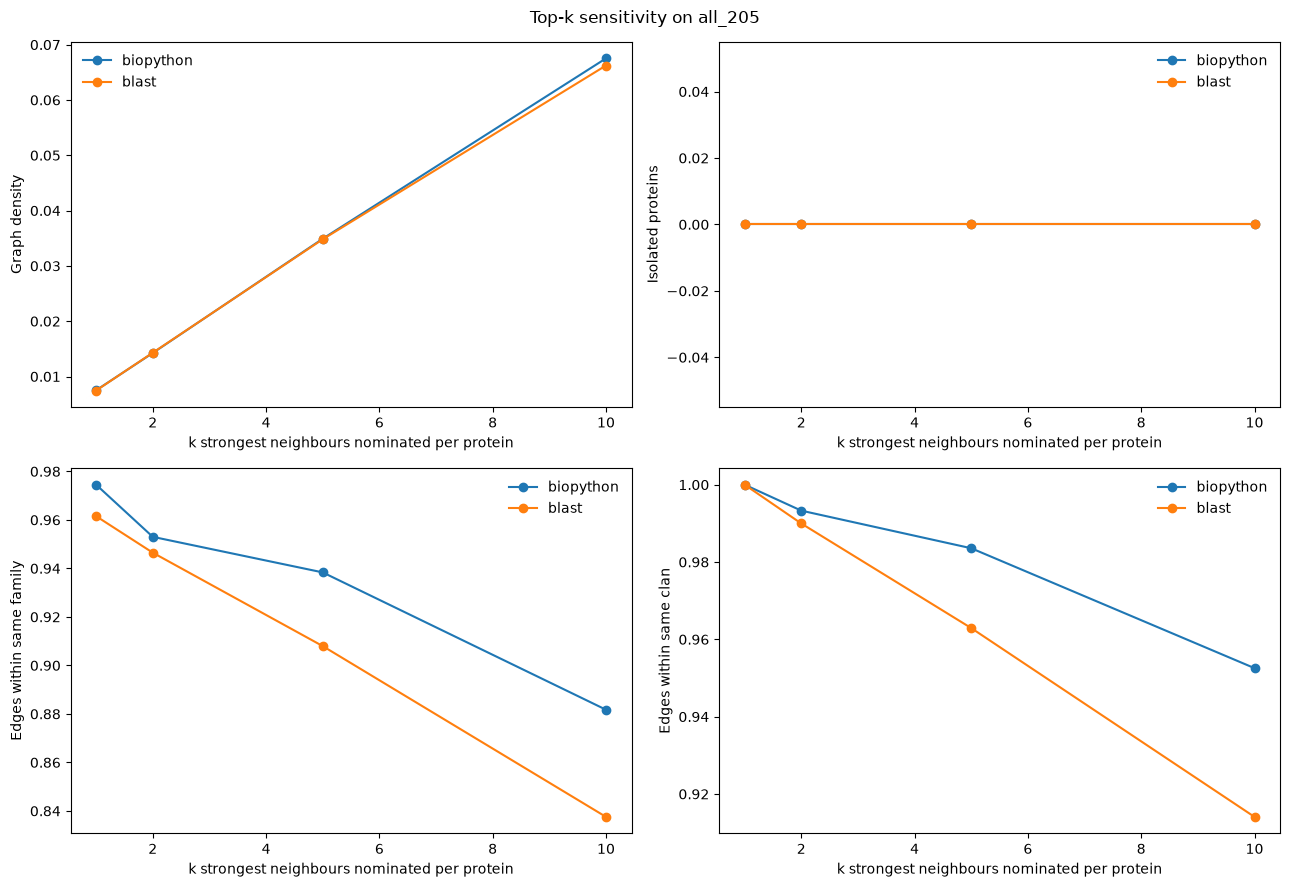

In [10]:
master_collection = f'all_{len(metadata)}'
figure, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics = [
    ('density', 'Graph density'),
    ('isolates', 'Isolated proteins'),
    ('same_family_edge_fraction', 'Edges within same family'),
    ('same_clan_edge_fraction', 'Edges within same clan'),
]
top_k_summary = graph_summaries.loc[
    (graph_summaries['collection_id'] == master_collection)
    & (graph_summaries['threshold_rule'] == 'top_k')
]
for axis, (metric, label) in zip(axes.flat, metrics, strict=True):
    for method, group in top_k_summary.groupby('method'):
        axis.plot(group['threshold'], group[metric], marker='o', label=method)
    axis.set_xlabel('k strongest neighbours nominated per protein')
    axis.set_ylabel(label)
    axis.legend(frameon=False)
figure.suptitle(f'Top-k sensitivity on {master_collection}')
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / 'top_k_sensitivity.png', dpi=180)
plt.show()

## A10. Visualise paired graphs

Method panels share node coordinates computed from edge-set union and use
common Pfam-family colours. Figure is saved under
`outputs/figures/pfam_clan_panel/`; GraphML, node, edge, and summary files are
stored under `outputs/graphs/pfam_clan_panel/`.


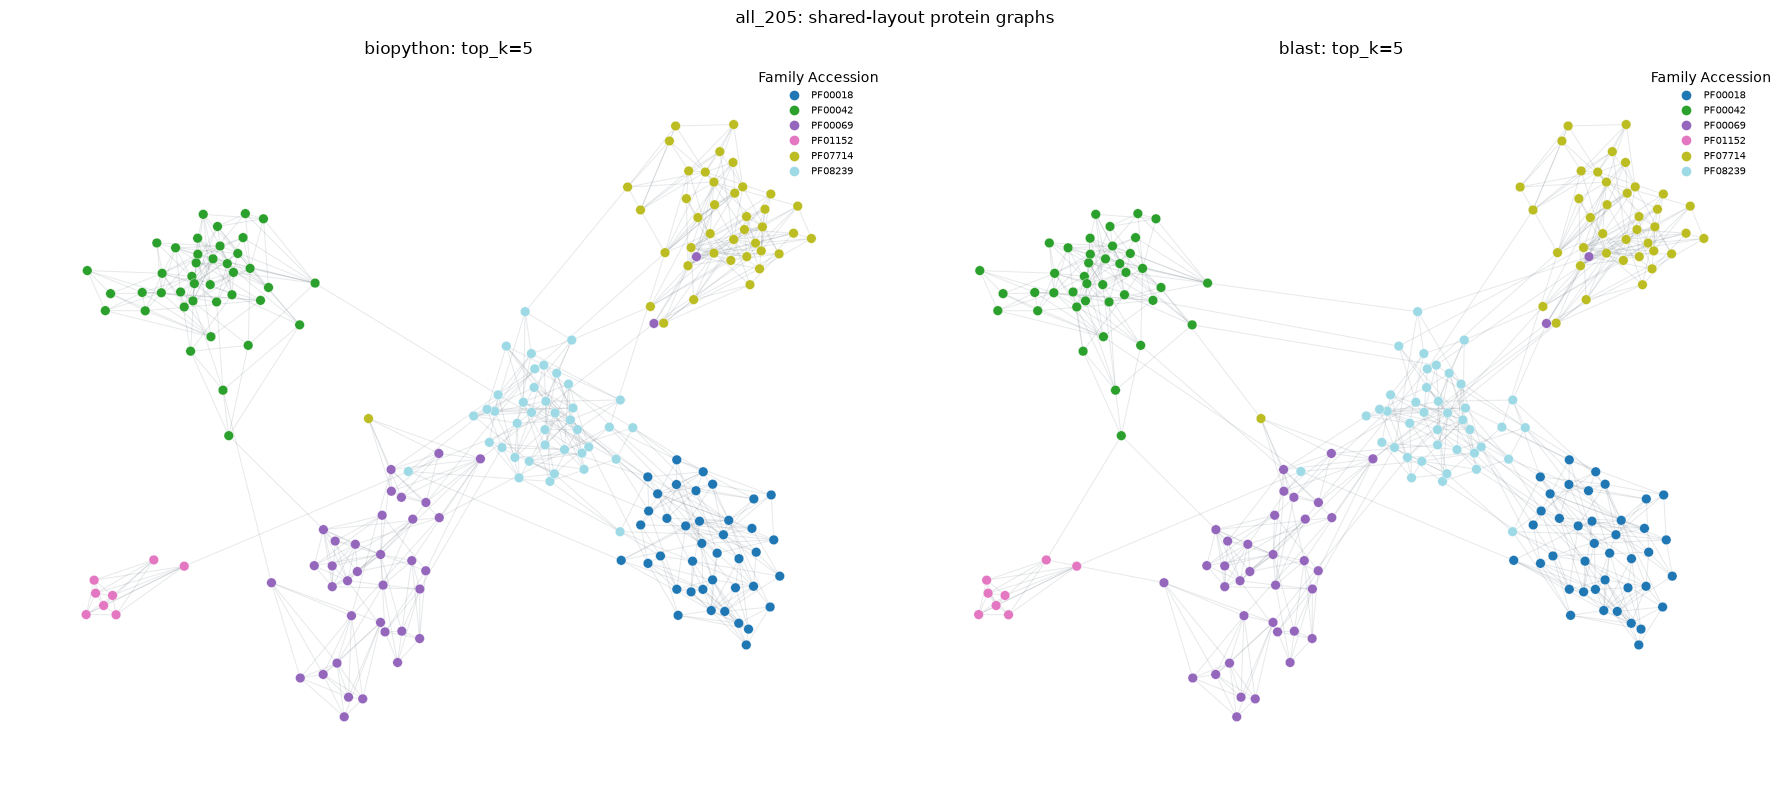

In [11]:
visual_graphs = {
    method: graph_cache[(master_collection, method, VISUAL_RULE, VISUAL_THRESHOLD)]
    for method in METHOD_COLUMNS
}
positions = shared_graph_layout(visual_graphs.values(), seed=RANDOM_SEED)
families = sorted(metadata['family_accession'].unique())
palette = plt.get_cmap('tab20', len(families))
family_colors = {family: palette(index) for index, family in enumerate(families)}
figure, axes = plt.subplots(1, len(visual_graphs), figsize=(9 * len(visual_graphs), 8))
axes = np.atleast_1d(axes)
for axis, (method, graph) in zip(axes, visual_graphs.items(), strict=True):
    draw_similarity_graph(
        graph, positions=positions, color_attribute='family_accession',
        category_colors=family_colors,
        title=f'{method}: {VISUAL_RULE}={VISUAL_THRESHOLD}',
        ax=axis, node_size=48, edge_alpha=0.16,
    )
figure.suptitle(f'{master_collection}: shared-layout protein graphs')
figure.tight_layout()
figure.savefig(
    FIGURE_DIRECTORY / f'{master_collection}_{VISUAL_RULE}_{VISUAL_THRESHOLD}.png',
    dpi=200,
)
plt.show()

for method, graph in visual_graphs.items():
    save_graph_bundle(
        graph,
        GRAPH_DIRECTORY / f'{master_collection}_{method}_{VISUAL_RULE}_{VISUAL_THRESHOLD}',
    )

## A11. Measure edge overlap

For edge sets $E_1,E_2$, Jaccard overlap is
$J(E_1,E_2)=\lvert E_1\cap E_2\rvert/\lvert E_1\cup E_2\rvert$. Cell displays selected settings and
stores all values in `outputs/tables/pfam_clan_panel/method_edge_overlap.tsv`.


In [12]:
def canonical_edges(graph):
    return {tuple(sorted(edge)) for edge in graph.edges}


overlap_rows = []
for collection_id in collections:
    for rule, thresholds in GRAPH_RULES.items():
        for threshold in thresholds:
            for method_a, method_b in combinations(METHOD_COLUMNS, 2):
                edges_a = canonical_edges(
                    graph_cache[(collection_id, method_a, rule, threshold)]
                )
                edges_b = canonical_edges(
                    graph_cache[(collection_id, method_b, rule, threshold)]
                )
                union = edges_a | edges_b
                overlap_rows.append({
                    'collection_id': collection_id,
                    'threshold_rule': rule,
                    'threshold': threshold,
                    'method_a': method_a, 'method_b': method_b,
                    'edges_a': len(edges_a), 'edges_b': len(edges_b),
                    'shared_edges': len(edges_a & edges_b),
                    'edge_jaccard': len(edges_a & edges_b) / len(union)
                    if union else np.nan,
                })
method_edge_overlap = pd.DataFrame(overlap_rows)
method_edge_overlap.to_csv(
    SCORE_DIRECTORY / 'method_edge_overlap.tsv', sep='\t', index=False
)
display(method_edge_overlap.loc[
    (method_edge_overlap['collection_id'] == master_collection)
    & (method_edge_overlap['threshold_rule'] == VISUAL_RULE)
])

,collection_id,threshold_rule,threshold,method_a,method_b,edges_a,edges_b,shared_edges,edge_jaccard
0,all_205,top_k,1.0,biopython,blast,157,156,128,0.691892
1,all_205,top_k,2.0,biopython,blast,298,299,255,0.745614
2,all_205,top_k,5.0,biopython,blast,730,728,612,0.723404
3,all_205,top_k,10.0,biopython,blast,1412,1385,1124,0.671847


# Part B — repeated-sampling experiment

## Question

How do collection composition, scoring method, and graph rule change recovery
of withheld Pfam family and clan labels?

Pfam labels constrain balanced sampling. Pair scoring, edge selection, and
Louvain use sequences or scores; evaluation then reveals labels.

## Factorial design

For condition $(c,f,r)$, sample $c$ clans, $f$ families per selected clan, and
$r$ domains per selected family. Collection size is $n=cfr$.

| Factor | Levels |
|---|---|
| $c$: clans | 2, 4, 8 |
| $f$: families per clan | 2, 3 |
| $r$: domains per family | 10, 20, 40 |

$3\times2\times3=18$ composition cells and 50 replicates per cell give
$18\times50=900$ collection declarations. Within each replicate, sampling is
uniform without replacement at clan, family, and domain levels. One realised
node set is reused across both methods and all 12 graph settings.

Graph settings comprise $k\in\{1,2,5,10\}$,
$p\in\{0.90,0.95,0.98,0.99\}$, and
$d\in\{0.005,0.01,0.02,0.05\}$.

## Reproducibility

- Stable hash of base seed and $(c,f,r)$ determines each replicate seed.
- Manifests record family, domain, seed, parameter, and checksum.
- Raw graph evaluations precede summaries and figures.
- Notebook reads empirical values from stored artifacts.


## B1. Build and audit sampling hierarchy

Three stages produce analysis collections:

1. `scripts/select_pfam_family_panel.py` filters official Pfam catalogue by
   recorded criteria, shuffles sorted candidates with fixed seed, and records
   every acceptance and rejection.
2. `scripts/prepare_pfam_clan_panel.py` downloads selected seed alignments and
   chooses fixed-size diverse domain panels deterministically.
3. `scripts/generate_pfam_collections.py` enumerates 18 conditions and samples
   clans, families within clans, and domains within families uniformly without
   replacement for 50 seeds.

`collection_manifest.tsv` stores one row and seed per declaration;
`collection_membership.tsv` stores node membership. Cell loads master panel and
both files, then calculates realised counts. B6 identifies duplicate node sets.


In [13]:
LARGE_PANEL_DIRECTORY = PROJECT_ROOT / 'data/processed/pfam_large_panel'
RESAMPLING_DIRECTORY = LARGE_PANEL_DIRECTORY / 'resampling'
RECOVERY_DIRECTORY = PROJECT_ROOT / 'outputs/tables/pfam_large_panel_graph_recovery_initial'
LARGE_FIGURE_DIRECTORY = PROJECT_ROOT / 'outputs/figures/pfam_large_panel'
LARGE_FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

large_metadata = pd.read_csv(
    LARGE_PANEL_DIRECTORY / 'pfam_large_panel_metadata.tsv', sep='\t'
)
sampling_manifest = pd.read_csv(
    RESAMPLING_DIRECTORY / 'collection_manifest.tsv', sep='\t'
)
recovery_results = pd.read_csv(
    RECOVERY_DIRECTORY / 'graph_recovery_results.tsv', sep='\t'
)

print(
    f'{len(large_metadata)} domains; '
    f"{large_metadata['family_accession'].nunique()} families; "
    f"{large_metadata['clan_accession'].nunique()} clans; "
    f'{len(sampling_manifest)} predeclared sampled collections'
)
display(
    large_metadata.groupby(
        ['clan_accession', 'clan_name', 'family_accession', 'family_name'],
        as_index=False,
    ).agg(domains=('node_id', 'size'))
)

960 domains; 24 families; 8 clans; 900 predeclared sampled collections


,clan_accession,clan_name,family_accession,family_name,domains
0,CL0148,Viral_Gag,PF00607,gag protein p24 N-terminal domain,40
1,CL0148,Viral_Gag,PF24925,Domain of unknown function (DUF7746),40
2,CL0148,Viral_Gag,PF28884,Petuvirus genome polyprotein domain,40
3,CL0261,NUDIX,PF00293,NUDIX domain,40
4,CL0261,NUDIX,PF03559,"NDP-hexose 2,3-dehydratase",40
5,CL0261,NUDIX,PF18290,Nudix hydrolase domain,40
6,CL0342,TolB_N,PF04052,TolB amino-terminal domain,40
7,CL0342,TolB_N,PF04390,Lipopolysaccharide-assembly,40
8,CL0342,TolB_N,PF29981,Domain of unknown function (DUF8603),40
9,CL0351,CHCH,PF02297,Cytochrome oxidase c subunit VIb,40


## B2. Inspect one fixed-design slice

Reference condition fixes $(c,f,r)=(4,2,20)$, hence $n=160$. Fifty collections,
Biopython, and $k\in\{1,2,5,10\}$ isolate variation across $k$. B3 loads full
factorial experiment.


,reference_label,threshold,graphs,median_nmi,lower_quartile_nmi,upper_quartile_nmi,median_ami,median_components,median_communities
0,clan_accession,1.0,50,0.565670,0.557259,0.574221,0.476396,37.5,37.5
1,clan_accession,2.0,50,0.700440,0.683294,0.715849,0.674775,11.0,15.0
2,clan_accession,5.0,50,0.762856,0.746904,0.781213,0.750126,4.0,10.0
3,clan_accession,10.0,50,0.800000,0.800000,0.826979,0.791650,1.0,8.0
4,family_accession,1.0,50,0.739584,0.725322,0.749994,0.628850,37.5,37.5
5,family_accession,2.0,50,0.877232,0.858665,0.894176,0.855078,11.0,15.0
6,family_accession,5.0,50,0.943556,0.925227,0.959595,0.936072,4.0,10.0
7,family_accession,10.0,50,0.978104,0.956522,1.000000,0.976095,1.0,8.0


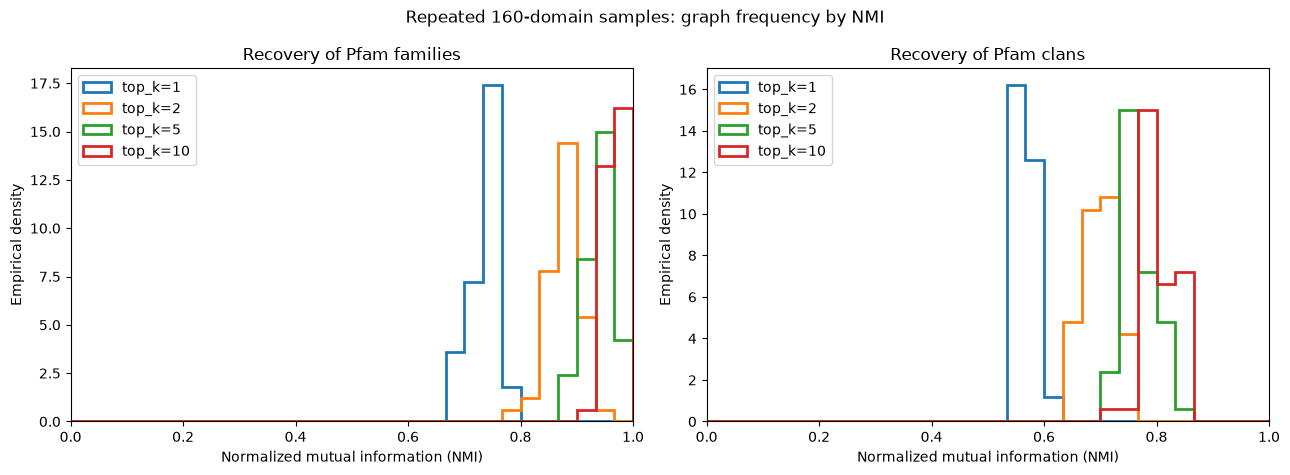

In [14]:
nmi_summary = (
    recovery_results
    .groupby(['reference_label', 'threshold'], as_index=False)
    .agg(
        graphs=('graph_id', 'nunique'),
        median_nmi=('nmi', 'median'),
        lower_quartile_nmi=('nmi', lambda values: values.quantile(0.25)),
        upper_quartile_nmi=('nmi', lambda values: values.quantile(0.75)),
        median_ami=('ami', 'median'),
        median_components=('connected_components', 'median'),
        median_communities=('inferred_community_count', 'median'),
    )
)
display(nmi_summary)

bins = np.linspace(0, 1, 31)
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
for axis, reference_label, title in zip(
    axes,
    ('family_accession', 'clan_accession'),
    ('Recovery of Pfam families', 'Recovery of Pfam clans'),
):
    subset = recovery_results.loc[
        recovery_results['reference_label'] == reference_label
    ]
    for threshold, group in subset.groupby('threshold'):
        axis.hist(
            group['nmi'], bins=bins, density=True, histtype='step',
            linewidth=2, label=f'top_k={int(threshold)}',
        )
    axis.set_title(title)
    axis.set_xlabel('Normalized mutual information (NMI)')
    axis.set_ylabel('Empirical density')
    axis.set_xlim(0, 1)
    axis.legend()
figure.suptitle('Repeated 160-domain samples: graph frequency by NMI')
figure.tight_layout()
figure.savefig(
    LARGE_FIGURE_DIRECTORY / 'initial_top_k_nmi_distributions.png', dpi=200
)
plt.show()

## B3. Load complete experiment

`scripts/run_resampled_graph_experiment.py` writes one row per graph and
reference-label level. One directory stores `top_k` and percentile results;
another stores target-density results. Cell loads raw tables and summaries,
checks expected rows, and calculates analysis sizes.

Raw tables retain all 18 conditions. Primary distributions retain conditions
whose 50 node-set fingerprints are distinct; B6 loads uniqueness audit.

Score manifest records BLAST per-query target cap and directionality. For
forward and reverse strongest HSP scores $s_f,s_r>0$, relative spread is
$\lvert s_f-s_r\rvert/\max(s_f,s_r)$.


In [15]:
FULL_RECOVERY_DIRECTORY = (
    PROJECT_ROOT / 'outputs/tables/pfam_large_panel_graph_recovery_full'
)
MATCHED_RECOVERY_DIRECTORY = (
    PROJECT_ROOT / 'outputs/tables/pfam_large_panel_graph_recovery_matched_density'
)
SUMMARY_DIRECTORY = PROJECT_ROOT / 'outputs/tables/pfam_large_panel_graph_summary'
FULL_FIGURE_DIRECTORY = PROJECT_ROOT / 'outputs/figures/pfam_large_panel_full'

full_results = pd.read_csv(
    FULL_RECOVERY_DIRECTORY / 'graph_recovery_results.tsv', sep='\t'
)
matched_results = pd.read_csv(
    MATCHED_RECOVERY_DIRECTORY / 'graph_recovery_results.tsv', sep='\t'
)
all_results = pd.concat([full_results, matched_results], ignore_index=True)

rule_summary = pd.read_csv(SUMMARY_DIRECTORY / 'rule_summary.tsv', sep='\t')
factor_summary = pd.read_csv(SUMMARY_DIRECTORY / 'factor_summary.tsv', sep='\t')
paired_method_summary = pd.read_csv(
    SUMMARY_DIRECTORY / 'paired_method_summary.tsv', sep='\t'
)
collection_uniqueness = pd.read_csv(
    SUMMARY_DIRECTORY / 'collection_uniqueness.tsv', sep='\t'
)
collection_fingerprints = pd.read_csv(
    SUMMARY_DIRECTORY / 'collection_fingerprints.tsv', sep='\t'
)
primary_collection_ids = set(
    collection_fingerprints.loc[
        collection_fingerprints['analysis_eligible'], 'collection_id'
    ]
)
primary_full_results = full_results.loc[
    full_results['collection_id'].isin(primary_collection_ids)
]
primary_matched_results = matched_results.loc[
    matched_results['collection_id'].isin(primary_collection_ids)
]
primary_results = pd.concat(
    [primary_full_results, primary_matched_results], ignore_index=True
)
score_manifest = json.loads(
    (PROJECT_ROOT / 'outputs/tables/pfam_large_panel_scores/run_manifest.json').read_text()
)

for name, table in [('full', full_results), ('matched-density', matched_results)]:
    print(
        f'{name:16s} graphs={table["graph_id"].nunique():6d}  '
        f'rows={len(table):6d}  collections={table["collection_id"].nunique():4d}  '
        f'missing NMI={int(table["nmi"].isna().sum())}  '
        f'zero-edge graphs={int((table["edges"] == 0).sum())}'
    )

primary_cell_count = int(collection_uniqueness['analysis_eligible'].sum())
primary_graph_count = pd.concat(
    [primary_full_results, primary_matched_results], ignore_index=True
)["graph_id"].nunique()
print(
    f'Primary distributional analysis: {len(primary_collection_ids)} collections, '
    f'{primary_cell_count} composition cells, {primary_graph_count:,} graphs'
)

display(
    all_results
    .groupby(['threshold_rule', 'method'], as_index=False)
    .agg(graphs=('graph_id', 'nunique'), rows=('nmi', 'size'))
)

blast_audit = score_manifest['parameters']['blast'].get('directionality_audit')
if blast_audit:
    display(pd.DataFrame([blast_audit]).rename_axis('BLAST directionality audit'))


full             graphs= 14400  rows= 28800  collections= 900  missing NMI=0  zero-edge graphs=0
matched-density  graphs=  7200  rows= 14400  collections= 900  missing NMI=0  zero-edge graphs=0
Primary distributional analysis: 700 collections, 14 composition cells, 16,800 graphs


,threshold_rule,method,graphs,rows
0,percentile,biopython,3600,7200
1,percentile,blast,3600,7200
2,target_density,biopython,3600,7200
3,target_density,blast,3600,7200
4,top_k,biopython,3600,7200
5,top_k,blast,3600,7200


,hsp_row_count,undirected_pair_count,bidirectional_pair_count,single_direction_pair_count,bidirectional_relative_spread_median,bidirectional_relative_spread_p90,bidirectional_relative_spread_max
BLAST directionality audit,,,,,,,
0,38399,19376,17744,1632,0.0,0.014922,0.614173


## B4. Compare equal percentiles

Percentile ranks available set $A_m$. BLAST coverage can therefore yield lower
density than Biopython at equal $p$. Cell loads `rule_summary.tsv` and compares
realised density, edge count, NMI, and AMI. Figure path:
`outputs/figures/pfam_large_panel_full/percentile_density_mismatch.png`.

Recovery differences at unequal density combine score, coverage, and edge
budget effects. B5 fixes edge budget.


,method,threshold,median_density,median_edges,median_nmi
0,biopython,0.90,0.100000,1270.5,0.914802
1,blast,0.90,0.008316,113.0,0.668801
2,biopython,0.95,0.050139,636.5,0.884988
3,blast,0.95,0.004202,57.0,0.644321
4,biopython,0.98,0.020043,255.0,0.749409
5,blast,0.98,0.001695,23.0,0.631627
6,biopython,0.99,0.010063,128.0,0.688985
7,blast,0.99,0.000901,12.0,0.623527


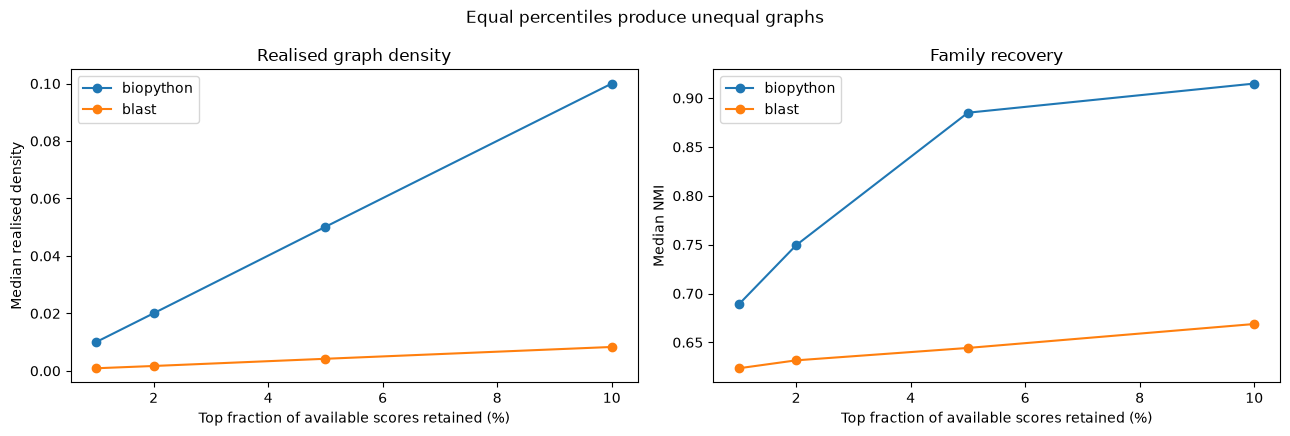

Three-panel version written by summary script: outputs/figures/pfam_large_panel_full/percentile_density_mismatch.png


In [16]:
percentile_view = rule_summary.loc[
    (rule_summary['threshold_rule'] == 'percentile')
    & (rule_summary['reference_label'] == 'family_accession')
]
display(
    percentile_view[
        ['method', 'threshold', 'median_density', 'median_edges', 'median_nmi']
    ].sort_values(['threshold', 'method'], ignore_index=True)
)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for axis, column, title, ylabel in zip(
    axes,
    ('median_density', 'median_nmi'),
    ('Realised graph density', 'Family recovery'),
    ('Median realised density', 'Median NMI'),
):
    for method, group in percentile_view.groupby('method'):
        ordered = group.sort_values('threshold')
        axis.plot(
            (1 - ordered['threshold']) * 100, ordered[column],
            marker='o', label=method,
        )
    axis.set_title(title)
    axis.set_xlabel('Top fraction of available scores retained (%)')
    axis.set_ylabel(ylabel)
    axis.legend()
figure.suptitle('Equal percentiles produce unequal graphs')
figure.tight_layout()
plt.show()

figure_path = FULL_FIGURE_DIRECTORY / 'percentile_density_mismatch.png'
print(f'Three-panel version written by summary script: {figure_path.relative_to(PROJECT_ROOT)}')

## B5. Compare matched edge budgets

For target $d$, each method retains up to $\lceil dP\rceil$ highest-scored
available pairs on identical nodes. Cell loads paired summaries, reports
absolute NMI differences, and calculates shortfalls. Primary comparisons
require zero shortfall for both methods; remaining settings are labelled
coverage stress tests. Figure path:
`outputs/figures/pfam_large_panel_full/matched_density_method_differences.png`.

Matching edge count preserves method-native relative weights. Weight
distributions can alter weighted Louvain partitions. `top_k` remains a local
neighbour rule with reported realised density.

Sensitivity run sets every retained weight to one. Results and manifest:
`outputs/tables/pfam_large_panel_graph_recovery_unweighted_reference/`.


In [17]:
display(
    paired_method_summary.loc[
        paired_method_summary['reference_label'] == 'family_accession',
        ['threshold_rule', 'threshold', 'pairs', 'comparison_status',
         'median_absolute_nmi_difference', 'median_density_difference'],
    ].sort_values(['threshold_rule', 'threshold'], ignore_index=True)
)

shortfall = matched_results.loc[matched_results['selection_shortfall'] > 0]
print(
    f'{len(shortfall)} of {len(matched_results)} matched-density rows have a '
    f'non-zero edge-budget shortfall; methods affected: '
    f'{sorted(shortfall["method"].unique())}; '
    f'densities affected: {sorted(shortfall["threshold"].unique())}'
)
display(
    shortfall
    .groupby(
        ['method', 'threshold', 'clans_per_collection',
         'families_per_clan', 'domains_per_family'],
        as_index=False,
    )
    .agg(
        rows=('nmi', 'size'),
        median_target_edges=('target_edges', 'median'),
        median_actual_edges=('edges', 'median'),
        median_shortfall=('selection_shortfall', 'median'),
    )
)

# Recompute the paired difference using only graphs where matching truly held.
paired = matched_results.pivot_table(
    index=['collection_id', 'threshold', 'reference_label'],
    columns='method',
    values='nmi',
).reset_index()
affected = (
    matched_results.loc[
        matched_results['selection_shortfall'] > 0,
        ['collection_id', 'threshold'],
    ]
    .drop_duplicates()
)
affected_keys = set(map(tuple, affected.to_numpy()))
paired['has_shortfall'] = [
    (collection, threshold) in affected_keys
    for collection, threshold in zip(paired['collection_id'], paired['threshold'])
]
paired['absolute_difference'] = (paired['blast'] - paired['biopython']).abs()

shortfall_effect = []
for (reference_label, threshold), group in paired.groupby(
    ['reference_label', 'threshold']
):
    fully_matched = group.loc[~group['has_shortfall']]
    shortfall_effect.append({
        'reference_label': reference_label,
        'threshold': threshold,
        'all_pairs': len(group),
        'median_absolute_difference_all': group['absolute_difference'].median(),
        'fully_matched_pairs': len(fully_matched),
        'median_absolute_difference_matched_only':
            fully_matched['absolute_difference'].median(),
    })
display(pd.DataFrame(shortfall_effect))

UNWEIGHTED_DIRECTORY = (
    PROJECT_ROOT
    / 'outputs/tables/pfam_large_panel_graph_recovery_unweighted_reference'
)
unweighted_results = pd.read_csv(
    UNWEIGHTED_DIRECTORY / 'graph_recovery_results.tsv', sep='	'
)
weighted_reference = all_results.loc[
    (all_results['clans_per_collection'] == 4)
    & (all_results['families_per_clan'] == 2)
    & (all_results['domains_per_family'] == 20)
    & (all_results['method'].isin(['biopython', 'blast']))
    & (
        ((all_results['threshold_rule'] == 'top_k') & (all_results['threshold'] == 5))
        | (
            (all_results['threshold_rule'] == 'target_density')
            & (all_results['threshold'] == 0.02)
        )
    )
].assign(weight_treatment='native score weights')
weight_sensitivity = pd.concat(
    [
        weighted_reference,
        unweighted_results.assign(weight_treatment='unweighted edges'),
    ],
    ignore_index=True,
)
display(
    weight_sensitivity.groupby(
        ['reference_label', 'method', 'threshold_rule', 'threshold',
         'weight_treatment'],
        as_index=False,
    ).agg(
        collections=('collection_id', 'nunique'),
        median_nmi=('nmi', 'median'),
        median_ami=('ami', 'median'),
        median_communities=('inferred_community_count', 'median'),
    )
)


,threshold_rule,threshold,pairs,comparison_status,median_absolute_nmi_difference,median_density_difference
0,percentile,0.900,700,diagnostic_unmatched_available_fraction,0.236503,-0.090330
1,percentile,0.950,700,diagnostic_unmatched_available_fraction,0.212151,-0.045868
2,percentile,0.980,700,diagnostic_unmatched_available_fraction,0.110131,-0.018351
3,percentile,0.990,700,diagnostic_unmatched_available_fraction,0.055342,-0.009177
4,target_density,0.005,700,primary_matched_edge_budget,0.001073,0.000000
5,target_density,0.010,700,primary_matched_edge_budget,0.001764,0.000000
6,target_density,0.020,700,primary_matched_edge_budget,0.003396,0.000000
7,target_density,0.050,700,stress_test_edge_budget_shortfall,0.009569,0.000000
8,top_k,1.000,700,local_neighbour_rule_realised_density,0.011246,-0.000046
9,top_k,2.000,700,local_neighbour_rule_realised_density,0.018515,-0.000118


320 of 14400 matched-density rows have a non-zero edge-budget shortfall; methods affected: ['blast']; densities affected: [np.float64(0.05)]


,method,threshold,clans_per_collection,families_per_clan,domains_per_family,rows,median_target_edges,median_actual_edges,median_shortfall
0,blast,0.05,8,2,10,20,636.0,623.5,12.5
1,blast,0.05,8,3,10,100,1434.0,1147.5,286.5
2,blast,0.05,8,3,20,100,5748.0,4760.5,987.5
3,blast,0.05,8,3,40,100,23016.0,19376.0,3640.0


,reference_label,threshold,all_pairs,median_absolute_difference_all,fully_matched_pairs,median_absolute_difference_matched_only
0,clan_accession,0.005,900,0.000948,900,0.000948
1,clan_accession,0.010,900,0.001394,900,0.001394
2,clan_accession,0.020,900,0.003162,900,0.003162
3,clan_accession,0.050,900,0.008552,740,0.006442
4,family_accession,0.005,900,0.001214,900,0.001214
5,family_accession,0.010,900,0.001795,900,0.001795
6,family_accession,0.020,900,0.003791,900,0.003791
7,family_accession,0.050,900,0.008127,740,0.008293


,reference_label,method,threshold_rule,threshold,weight_treatment,collections,median_nmi,median_ami,median_communities
0,clan_accession,biopython,target_density,0.02,native score weights,50,0.524982,0.326562,87.5
1,clan_accession,biopython,target_density,0.02,unweighted edges,50,0.525410,0.326562,87.0
2,clan_accession,biopython,top_k,5.00,native score weights,50,0.762856,0.750126,10.0
3,clan_accession,biopython,top_k,5.00,unweighted edges,50,0.780557,0.769554,9.0
4,clan_accession,blast,target_density,0.02,native score weights,50,0.519804,0.320136,89.0
5,clan_accession,blast,target_density,0.02,unweighted edges,50,0.520281,0.322682,88.0
6,clan_accession,blast,top_k,5.00,native score weights,50,0.746149,0.732304,10.0
7,clan_accession,blast,top_k,5.00,unweighted edges,50,0.756577,0.743494,9.0
8,family_accession,biopython,target_density,0.02,native score weights,50,0.696036,0.476038,87.5
9,family_accession,biopython,target_density,0.02,unweighted edges,50,0.696379,0.480682,87.0


## B6. Audit replicate uniqueness

Saturated conditions can repeat node sets because requested samples exhaust
available choices. Script hashes sorted node IDs, counts distinct fingerprints
within each condition, and writes `collection_uniqueness.tsv`. Primary rule
retains a condition iff all 50 fingerprints are distinct. Cell calculates
excluded conditions and repeated declarations from audit table.


In [18]:
display(collection_uniqueness)

degenerate = collection_uniqueness.loc[
    collection_uniqueness['duplicate_collection_count'] > 0
]
print(
    f'{len(degenerate)} of {len(collection_uniqueness)} composition cells contain '
    f'duplicate node sets; '
    f'{int(degenerate["duplicate_collection_count"].sum())} of their '
    f'{int(degenerate["declared_collections"].sum())} '
    'collection declarations repeat an earlier node set.'
)
print(
    'Fully independent cells: '
    f'{int(collection_uniqueness["analysis_eligible"].sum())}; '
    f'primary collections: {len(primary_collection_ids)}'
)

if not degenerate.empty:
    print(
        'Composition levels represented among audit-only cells — '
        f'domains/family: {sorted(degenerate["domains_per_family"].unique())}; '
        f'families/clan: {sorted(degenerate["families_per_clan"].unique())}; '
        f'clans: {sorted(degenerate["clans_per_collection"].unique())}'
    )


,clans_per_collection,families_per_clan,domains_per_family,declared_collections,unique_node_sets,duplicate_collection_count,analysis_eligible,analysis_status
0,2,2,10,50,50,0,True,primary_independent_replicates
1,2,2,20,50,50,0,True,primary_independent_replicates
2,2,2,40,50,46,4,False,audit_only_repeated_node_sets
3,2,3,10,50,50,0,True,primary_independent_replicates
4,2,3,20,50,50,0,True,primary_independent_replicates
5,2,3,40,50,23,27,False,audit_only_repeated_node_sets
6,4,2,10,50,50,0,True,primary_independent_replicates
7,4,2,20,50,50,0,True,primary_independent_replicates
8,4,2,40,50,50,0,True,primary_independent_replicates
9,4,3,10,50,50,0,True,primary_independent_replicates


4 of 18 composition cells contain duplicate node sets; 100 of their 200 collection declarations repeat an earlier node set.
Fully independent cells: 14; primary collections: 700
Composition levels represented among audit-only cells — domains/family: [np.int64(40)]; families/clan: [np.int64(2), np.int64(3)]; clans: [np.int64(2), np.int64(4), np.int64(8)]


## B7. Compare descriptive effect sizes

Let $\widetilde a(\ell,z)$ be median family NMI or AMI for factor level $\ell$
with all other settings $z$ fixed. Factor spread is

$$
R(z)=\max_{\ell}\widetilde a(\ell,z)-\min_{\ell}\widetilde a(\ell,z).
$$

Cell reports median and maximum $R(z)$ across valid $z$ for graph setting,
collection composition, and method. These ranges describe observed variation;
they provide no causal or significance estimate.

Method spreads are separated by rule family. Target density supplies matched
budgets; `top_k` includes realised density; percentile remains coverage
diagnostic. Final table compares one local and one global Biopython setting
with nearby median densities.


In [19]:
family_medians = (
    primary_results.loc[
        primary_results['reference_label'] == 'family_accession'
    ]
    .groupby(
        ['clans_per_collection', 'families_per_clan', 'domains_per_family',
         'method', 'threshold_rule', 'threshold'],
        as_index=False,
    )
    .agg(median_nmi=('nmi', 'median'), median_ami=('ami', 'median'))
)
composition_columns = [
    'clans_per_collection', 'families_per_clan', 'domains_per_family',
]
rule_columns = ['threshold_rule', 'threshold']


def spread_holding_fixed(table, held_fixed, metric):
    """Median and largest metric range within each held-fixed group.

    Everything not named in ``held_fixed`` is the factor being varied, so the
    range inside a group is that factor's effect at one fixed setting of the
    others.
    """
    ranges = table.groupby(held_fixed)[metric].agg(
        lambda values: values.max() - values.min()
    )
    return ranges.median(), ranges.max(), len(ranges)


effect_rows = []
for measure, metric in [('NMI', 'median_nmi'), ('AMI', 'median_ami')]:
    effects = {
        'graph setting (rule + parameter)': spread_holding_fixed(
            family_medians, composition_columns + ['method'], metric
        ),
        'collection composition': spread_holding_fixed(
            family_medians, ['method'] + rule_columns, metric
        ),
        'alignment method': spread_holding_fixed(
            family_medians, composition_columns + rule_columns, metric
        ),
    }
    for rule in ('top_k', 'percentile', 'target_density'):
        effects[f'alignment method | {rule} only'] = spread_holding_fixed(
            family_medians.loc[family_medians['threshold_rule'] == rule],
            composition_columns + rule_columns, metric,
        )
    for name, (median_spread, largest_spread, comparisons) in effects.items():
        effect_rows.append({
            'measure': measure, 'factor varied': name,
            'median spread': median_spread, 'largest spread': largest_spread,
            'comparisons': comparisons,
        })

effect_summary = pd.DataFrame(effect_rows)
display(effect_summary)

# Nearby-density diagnostic; exact matching requires identical edge counts.
nearby_density_rule_comparison = rule_summary.loc[
    (rule_summary['reference_label'] == 'family_accession')
    & (rule_summary['method'] == 'biopython')
    & (
        ((rule_summary['threshold_rule'] == 'top_k') & (rule_summary['threshold'] == 5))
        | (
            (rule_summary['threshold_rule'] == 'target_density')
            & (rule_summary['threshold'] == 0.05)
        )
    ),
    ['threshold_rule', 'threshold', 'graphs', 'median_density',
     'median_nmi', 'median_ami'],
]
display(nearby_density_rule_comparison)


,measure,factor varied,median spread,largest spread,comparisons
0,NMI,graph setting (rule + parameter),0.325200,0.462976,28
1,NMI,collection composition,0.246795,0.372394,24
2,NMI,alignment method,0.014467,0.393382,168
3,NMI,alignment method | top_k only,0.014085,0.082736,56
4,NMI,alignment method | percentile only,0.140010,0.393382,56
5,NMI,alignment method | target_density only,0.001657,0.034545,56
6,AMI,graph setting (rule + parameter),0.858752,0.910284,28
7,AMI,collection composition,0.240876,0.622373,24
8,AMI,alignment method,0.019850,0.797948,168
9,AMI,alignment method | top_k only,0.019664,0.096033,56


,threshold_rule,threshold,graphs,median_density,median_nmi,median_ami
31,target_density,0.05,700,0.050000,0.886441,0.852915
34,top_k,5.00,700,0.041824,0.948931,0.938142


## B8. Generate report figures and load null control

`scripts/build_report_assets.py` reads stored artifacts, generates twelve
canonical PNGs under `outputs/figures/pfam_large_panel_report/`, and copies
identical files into `report/figures/`. `report/figure_provenance.tsv` records
producer, input artifacts, paths, and SHA-256 checksums. Cell invokes script
and displays canonical files.

Score-permutation control replaces each edge score $s_e$ by $s_{\pi(e)}$ for a
fixed permutation $\pi$ of available pairs, preserving node set and score
multiset while removing pair identity. Cell compares
permuted results with matching observed graphs.


Figures generated under /Users/davin/Desktop/Protein Seq Alignment/outputs/figures/pfam_large_panel_report and copied to /Users/davin/Desktop/Protein Seq Alignment/report/figures


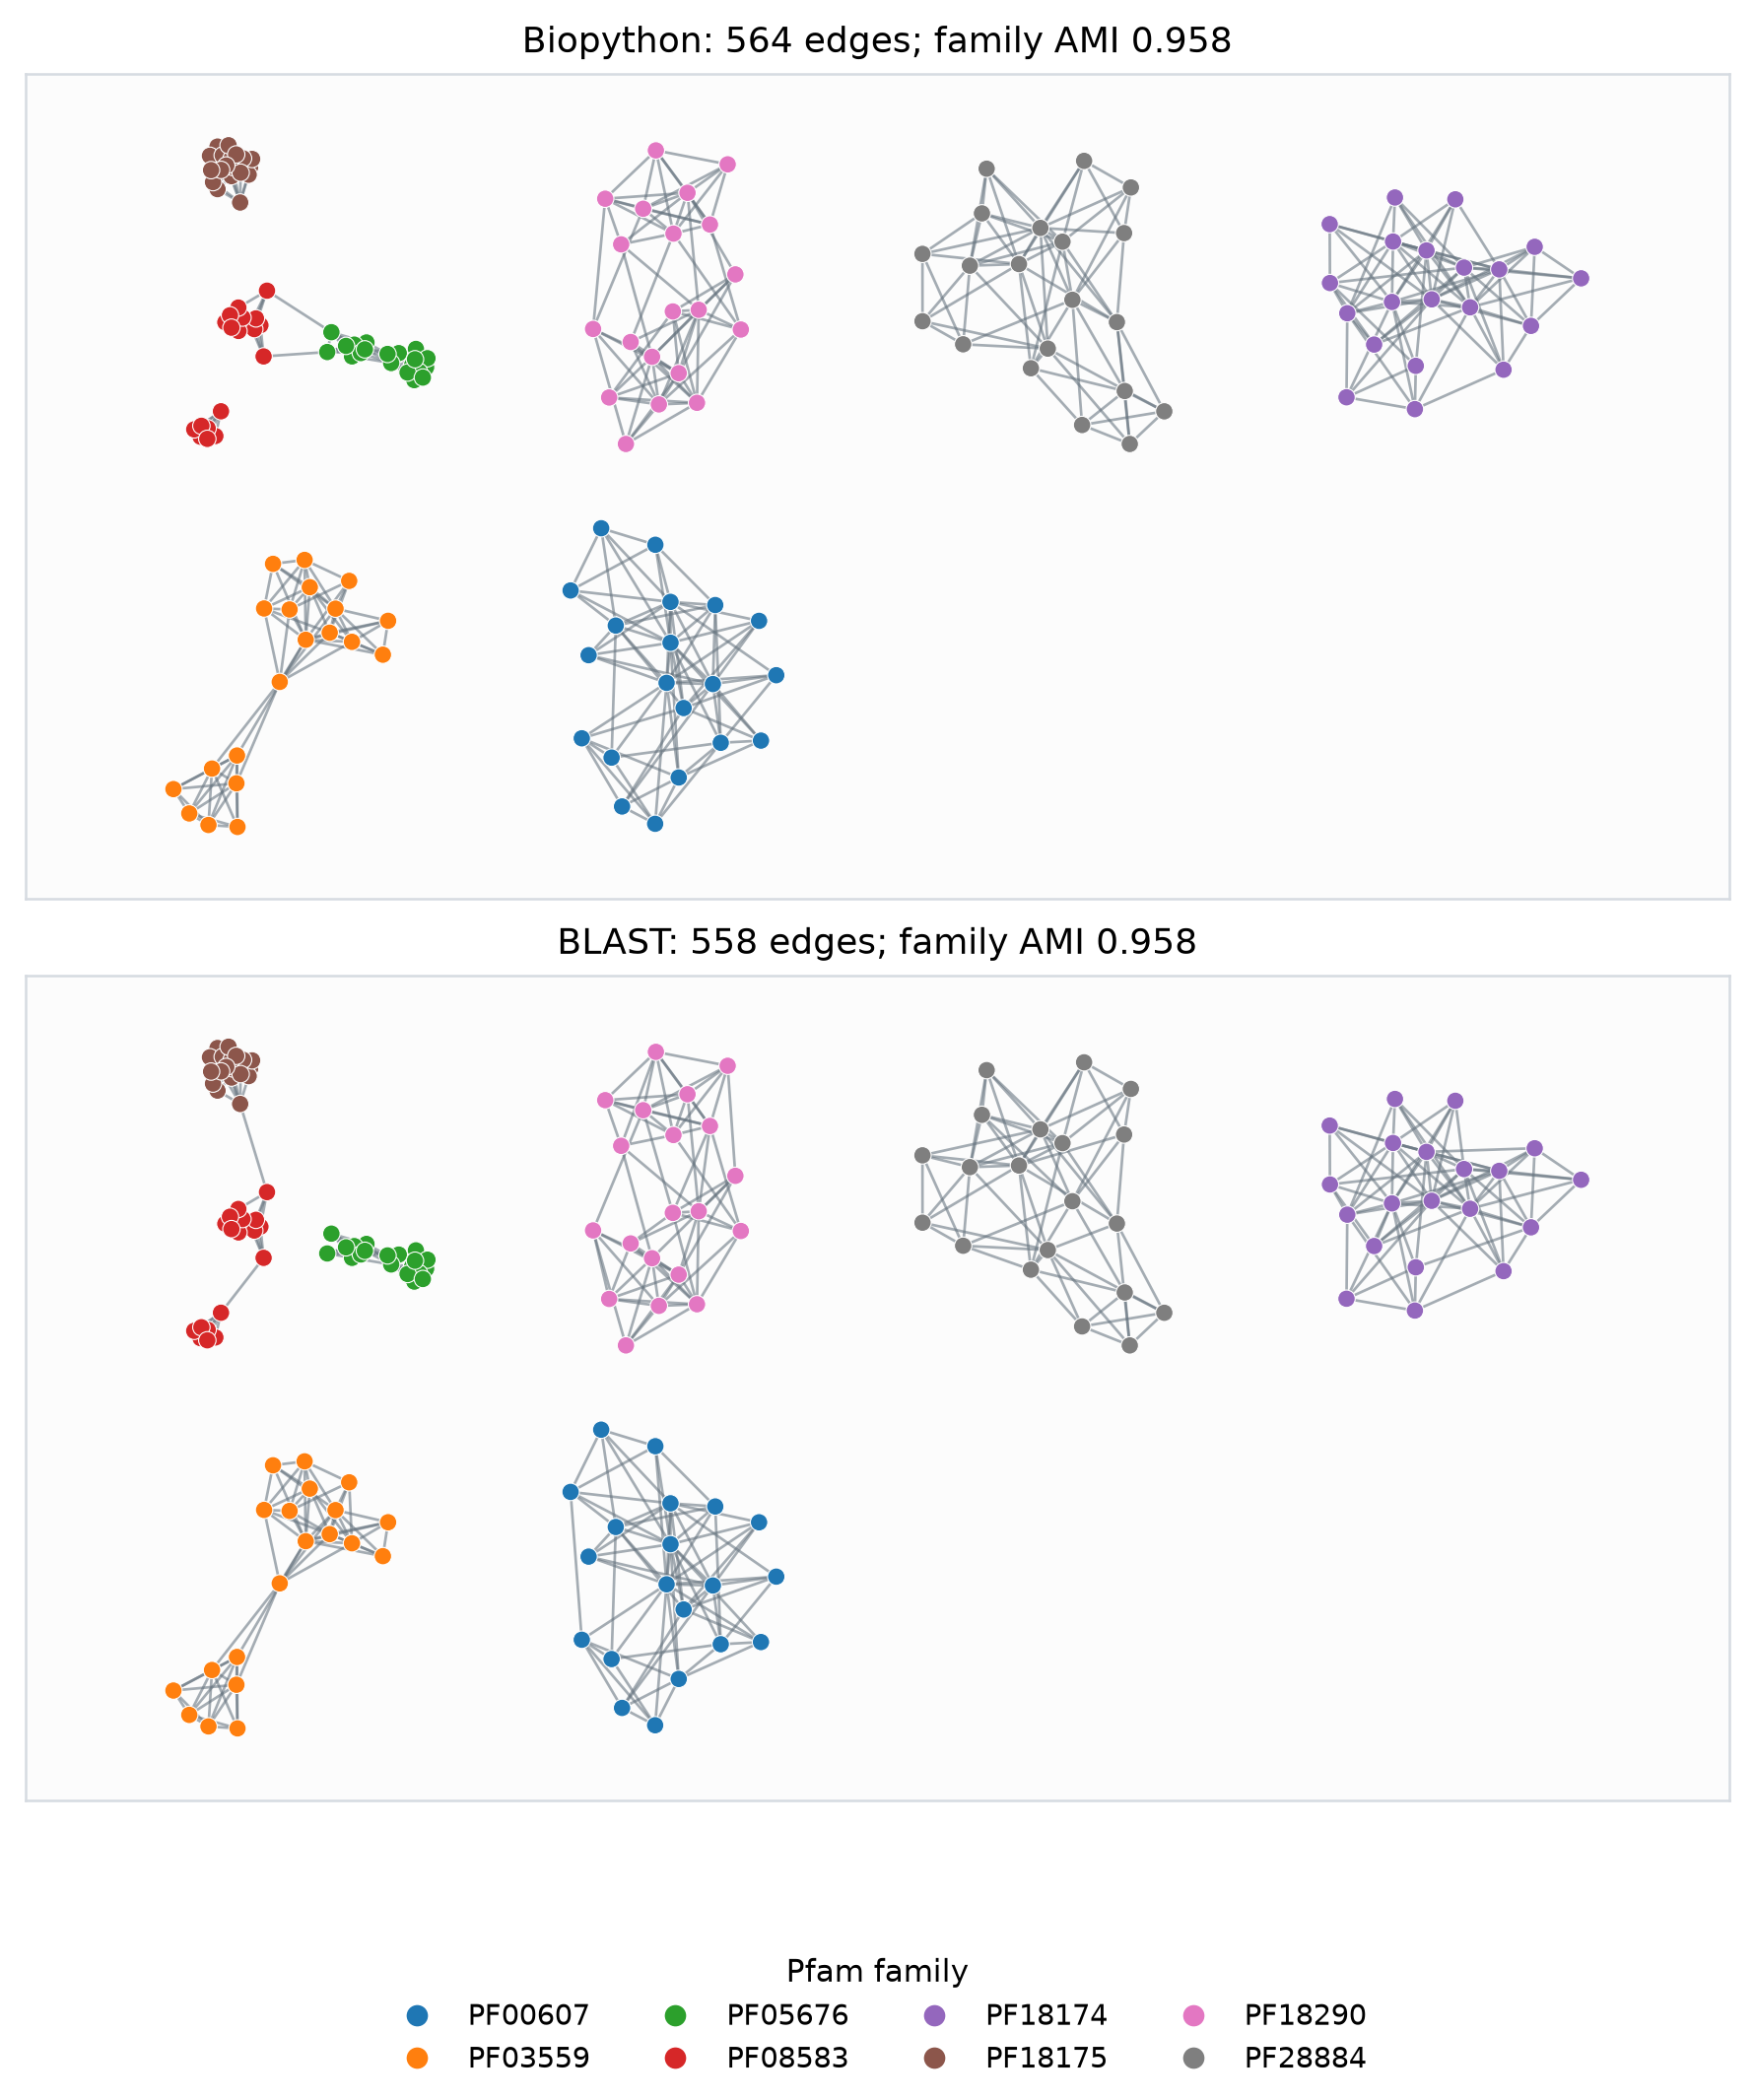

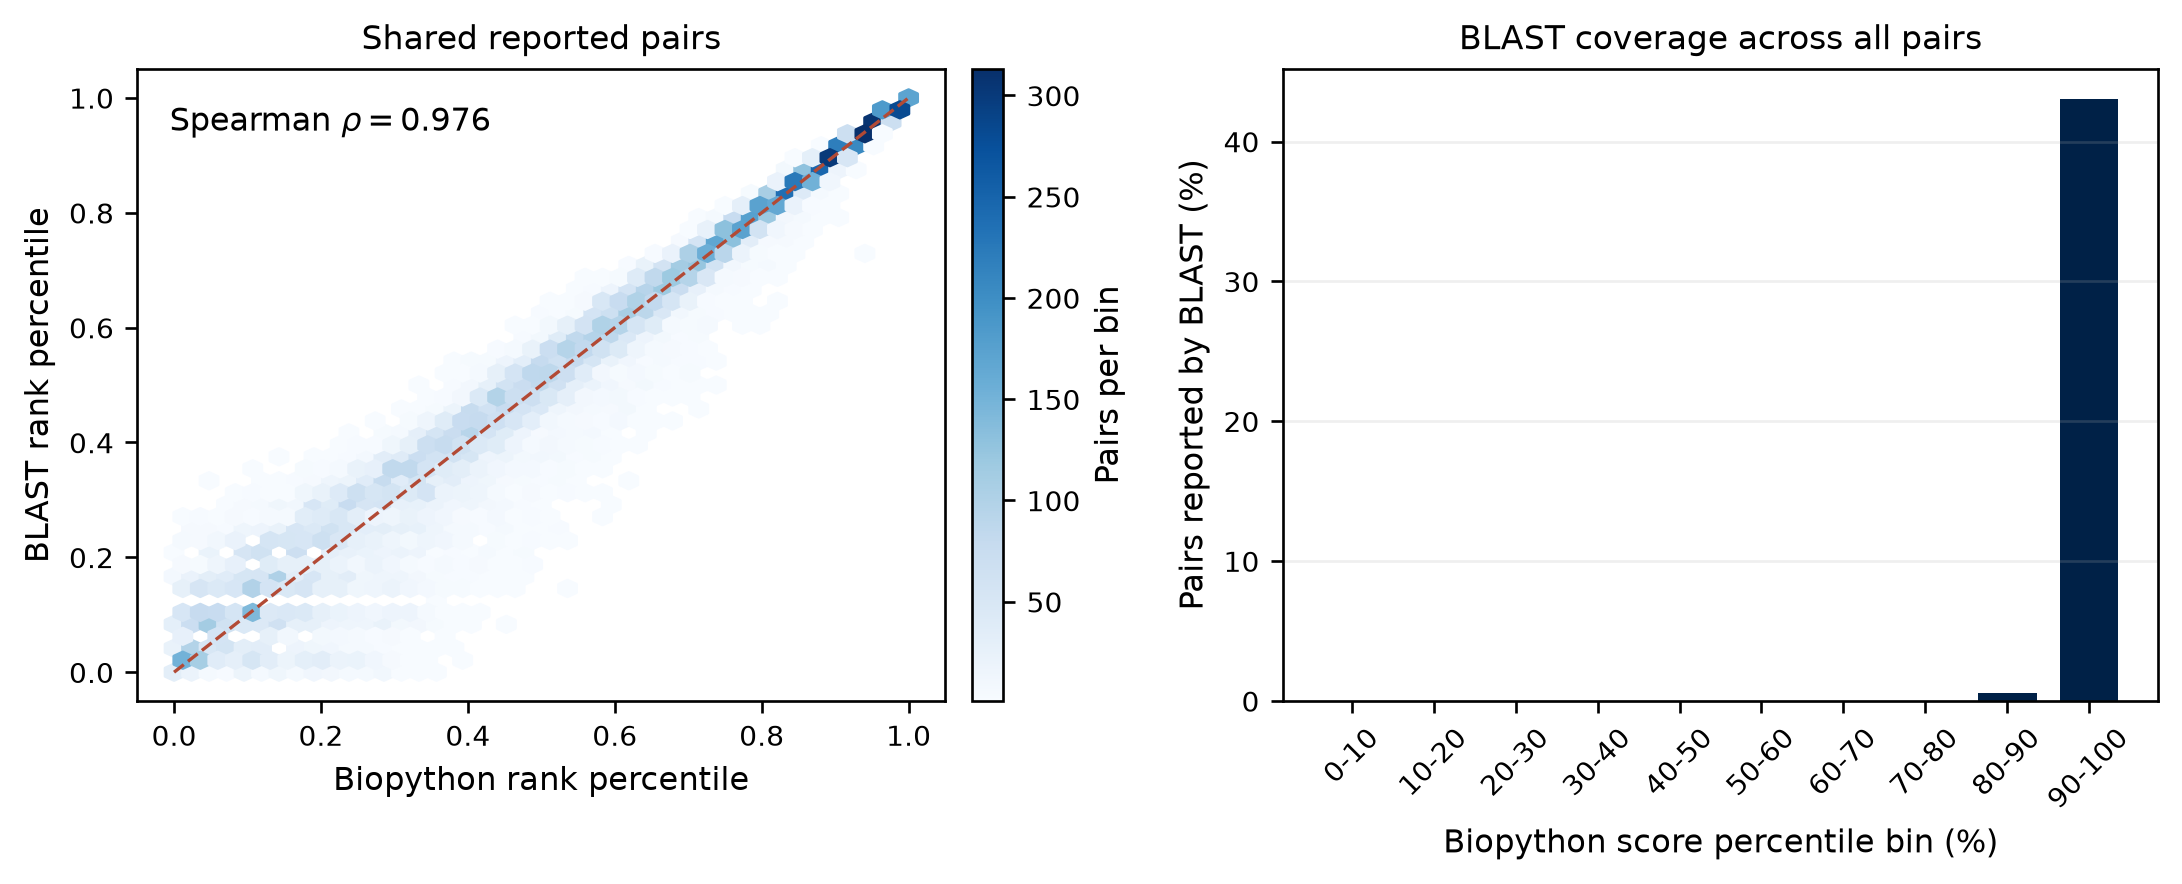

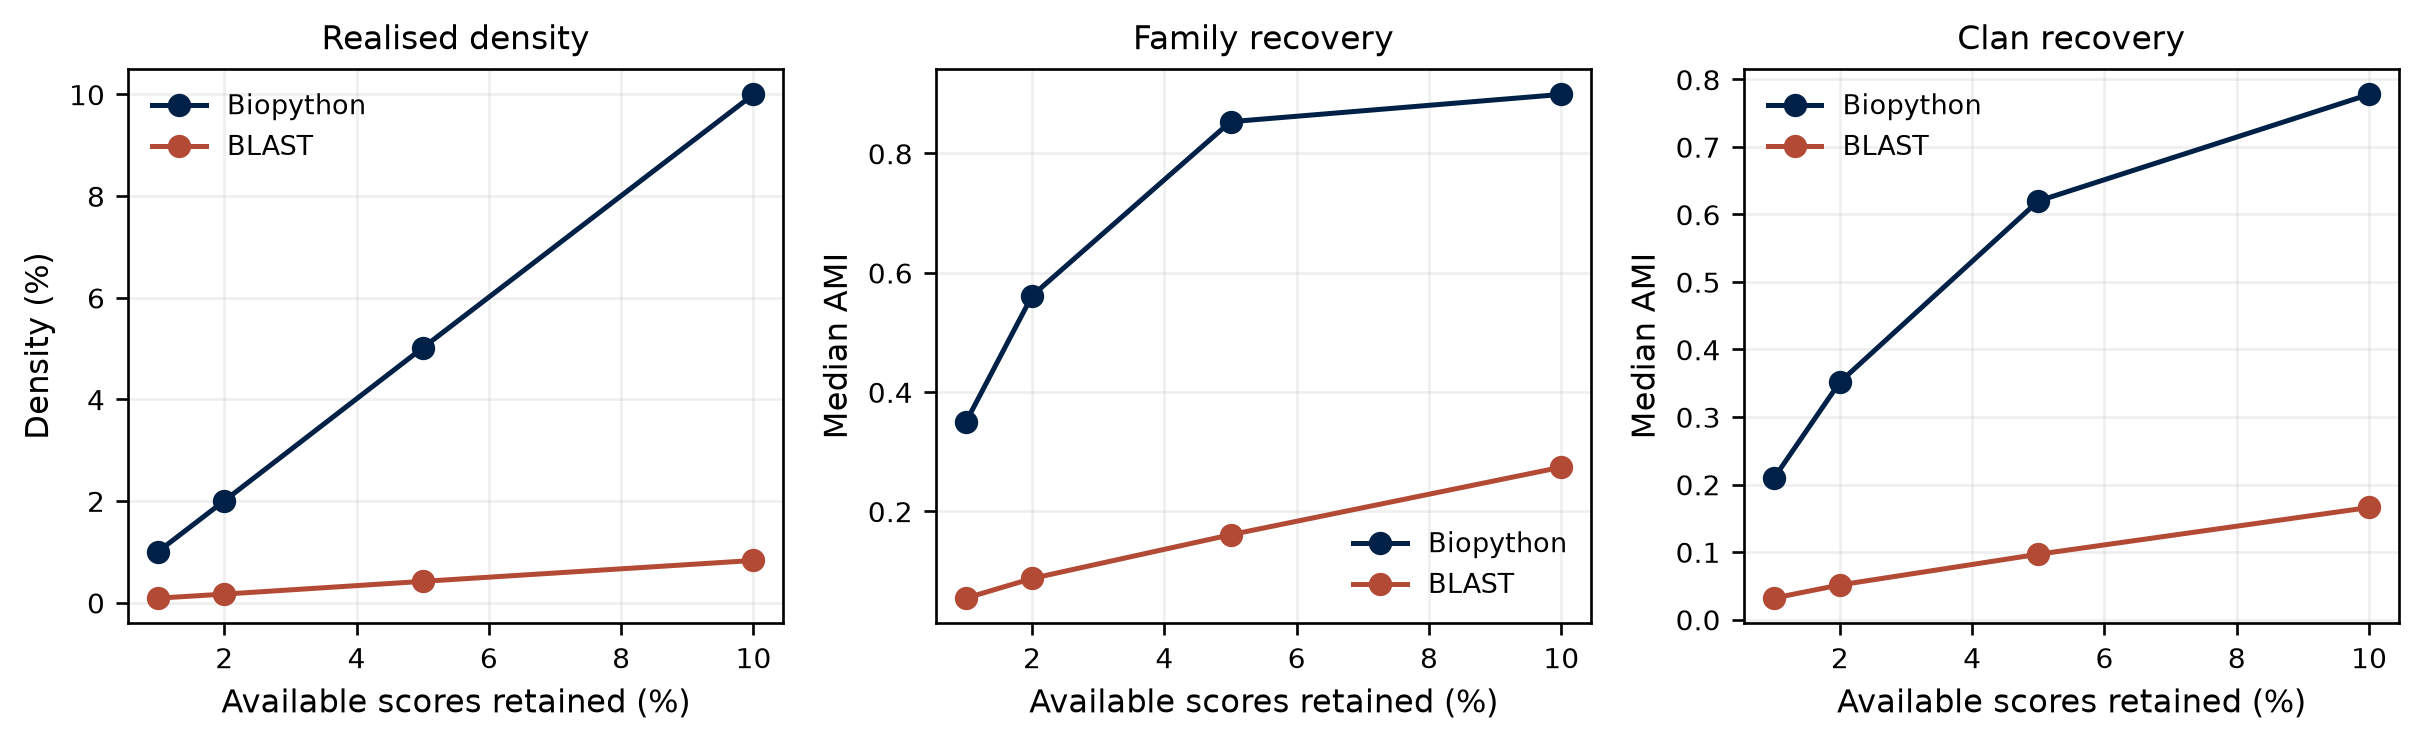

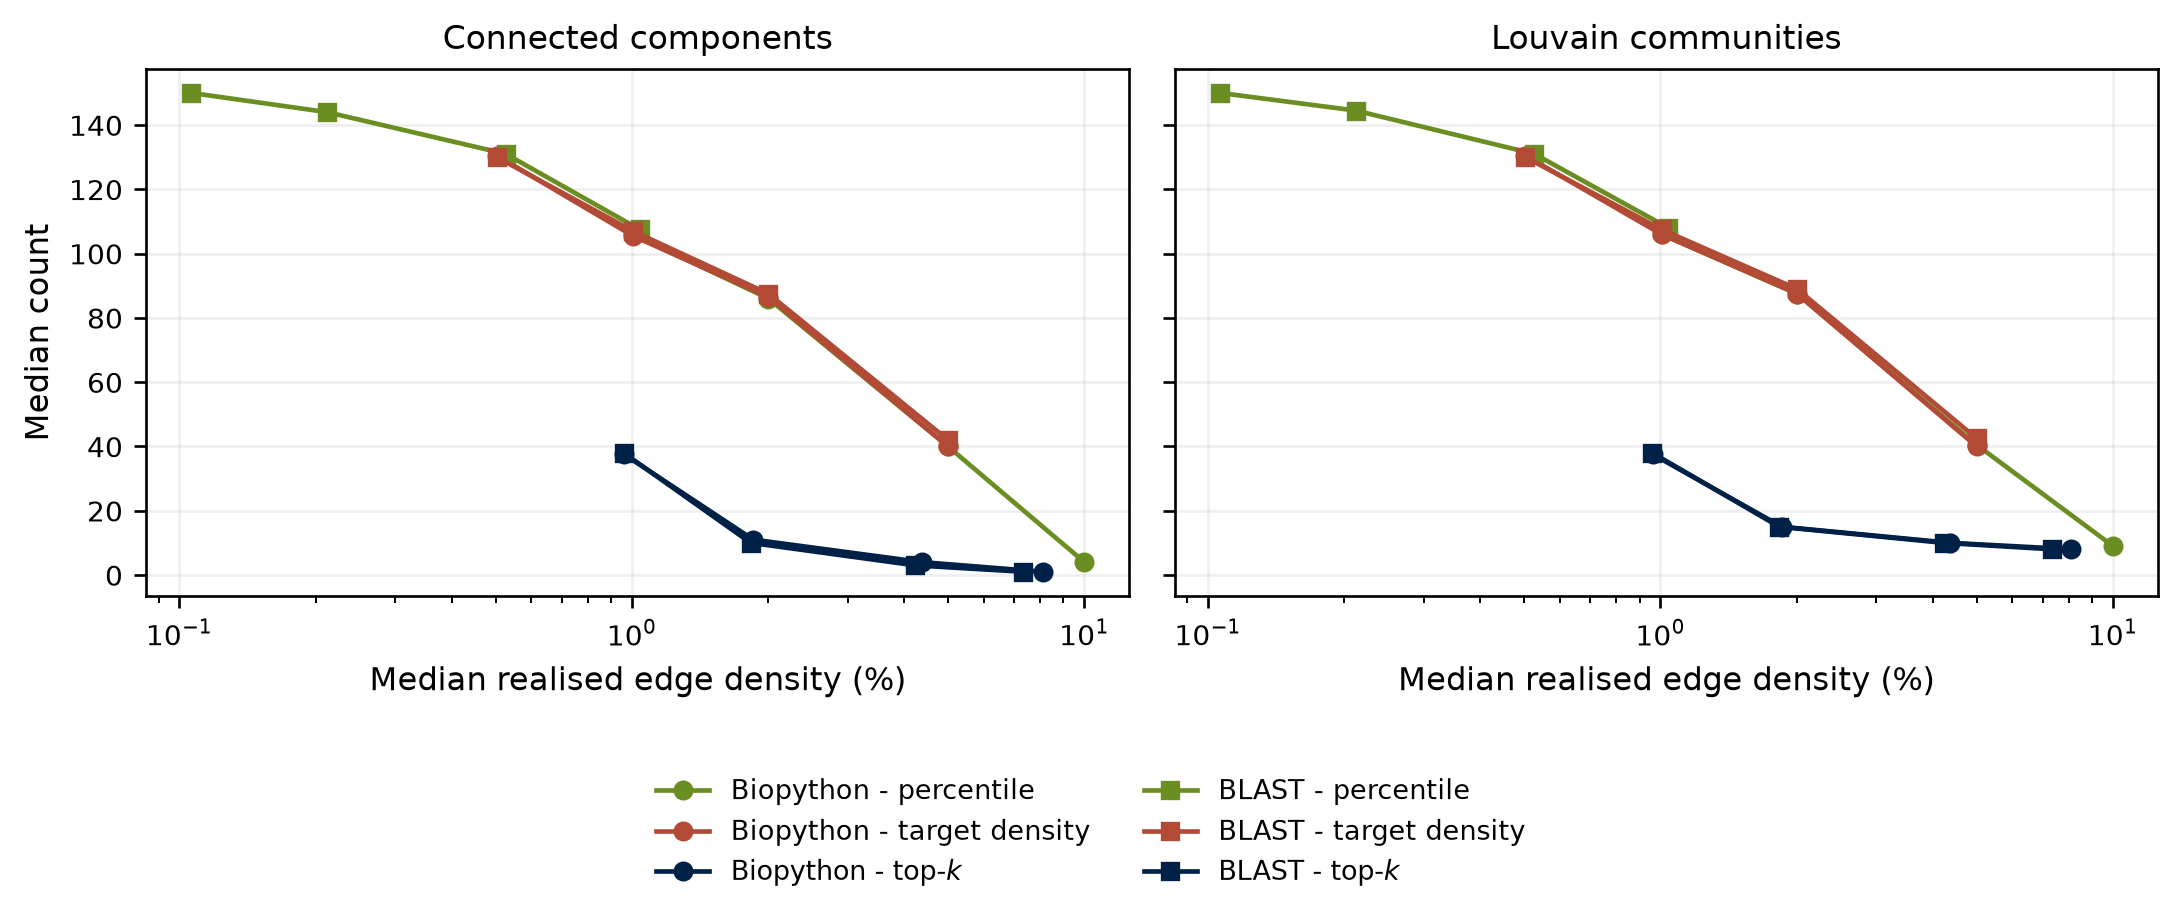

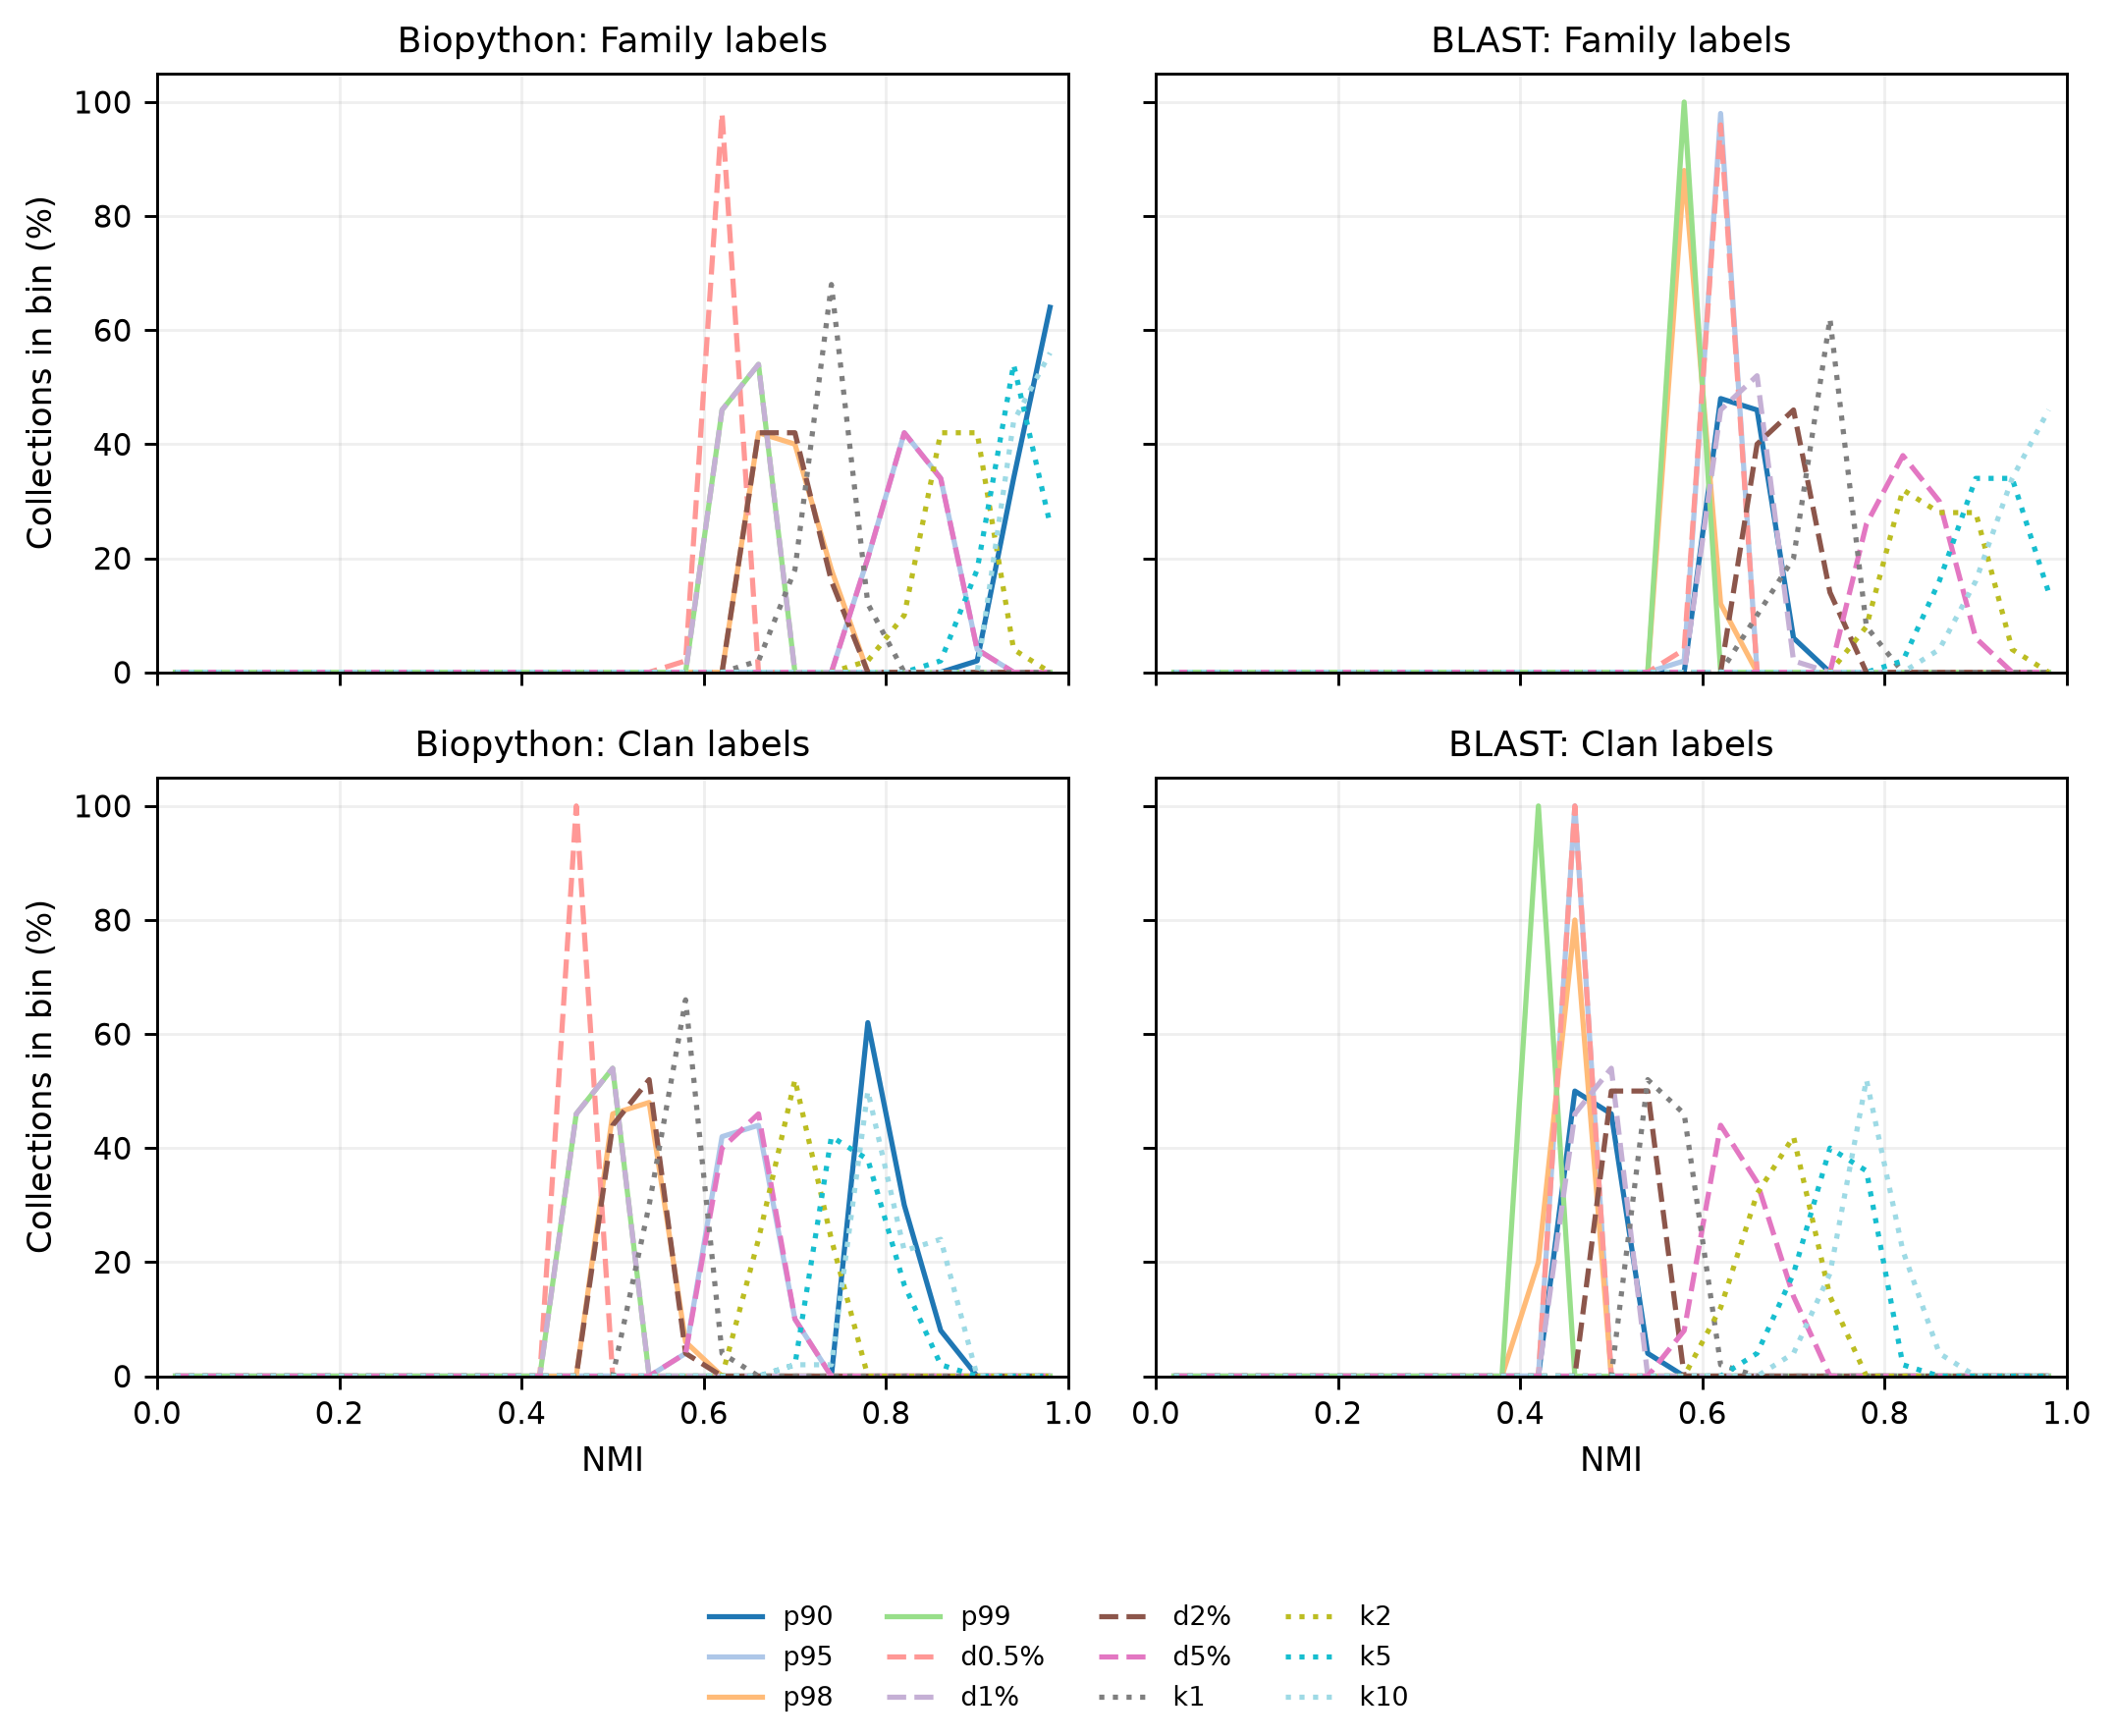

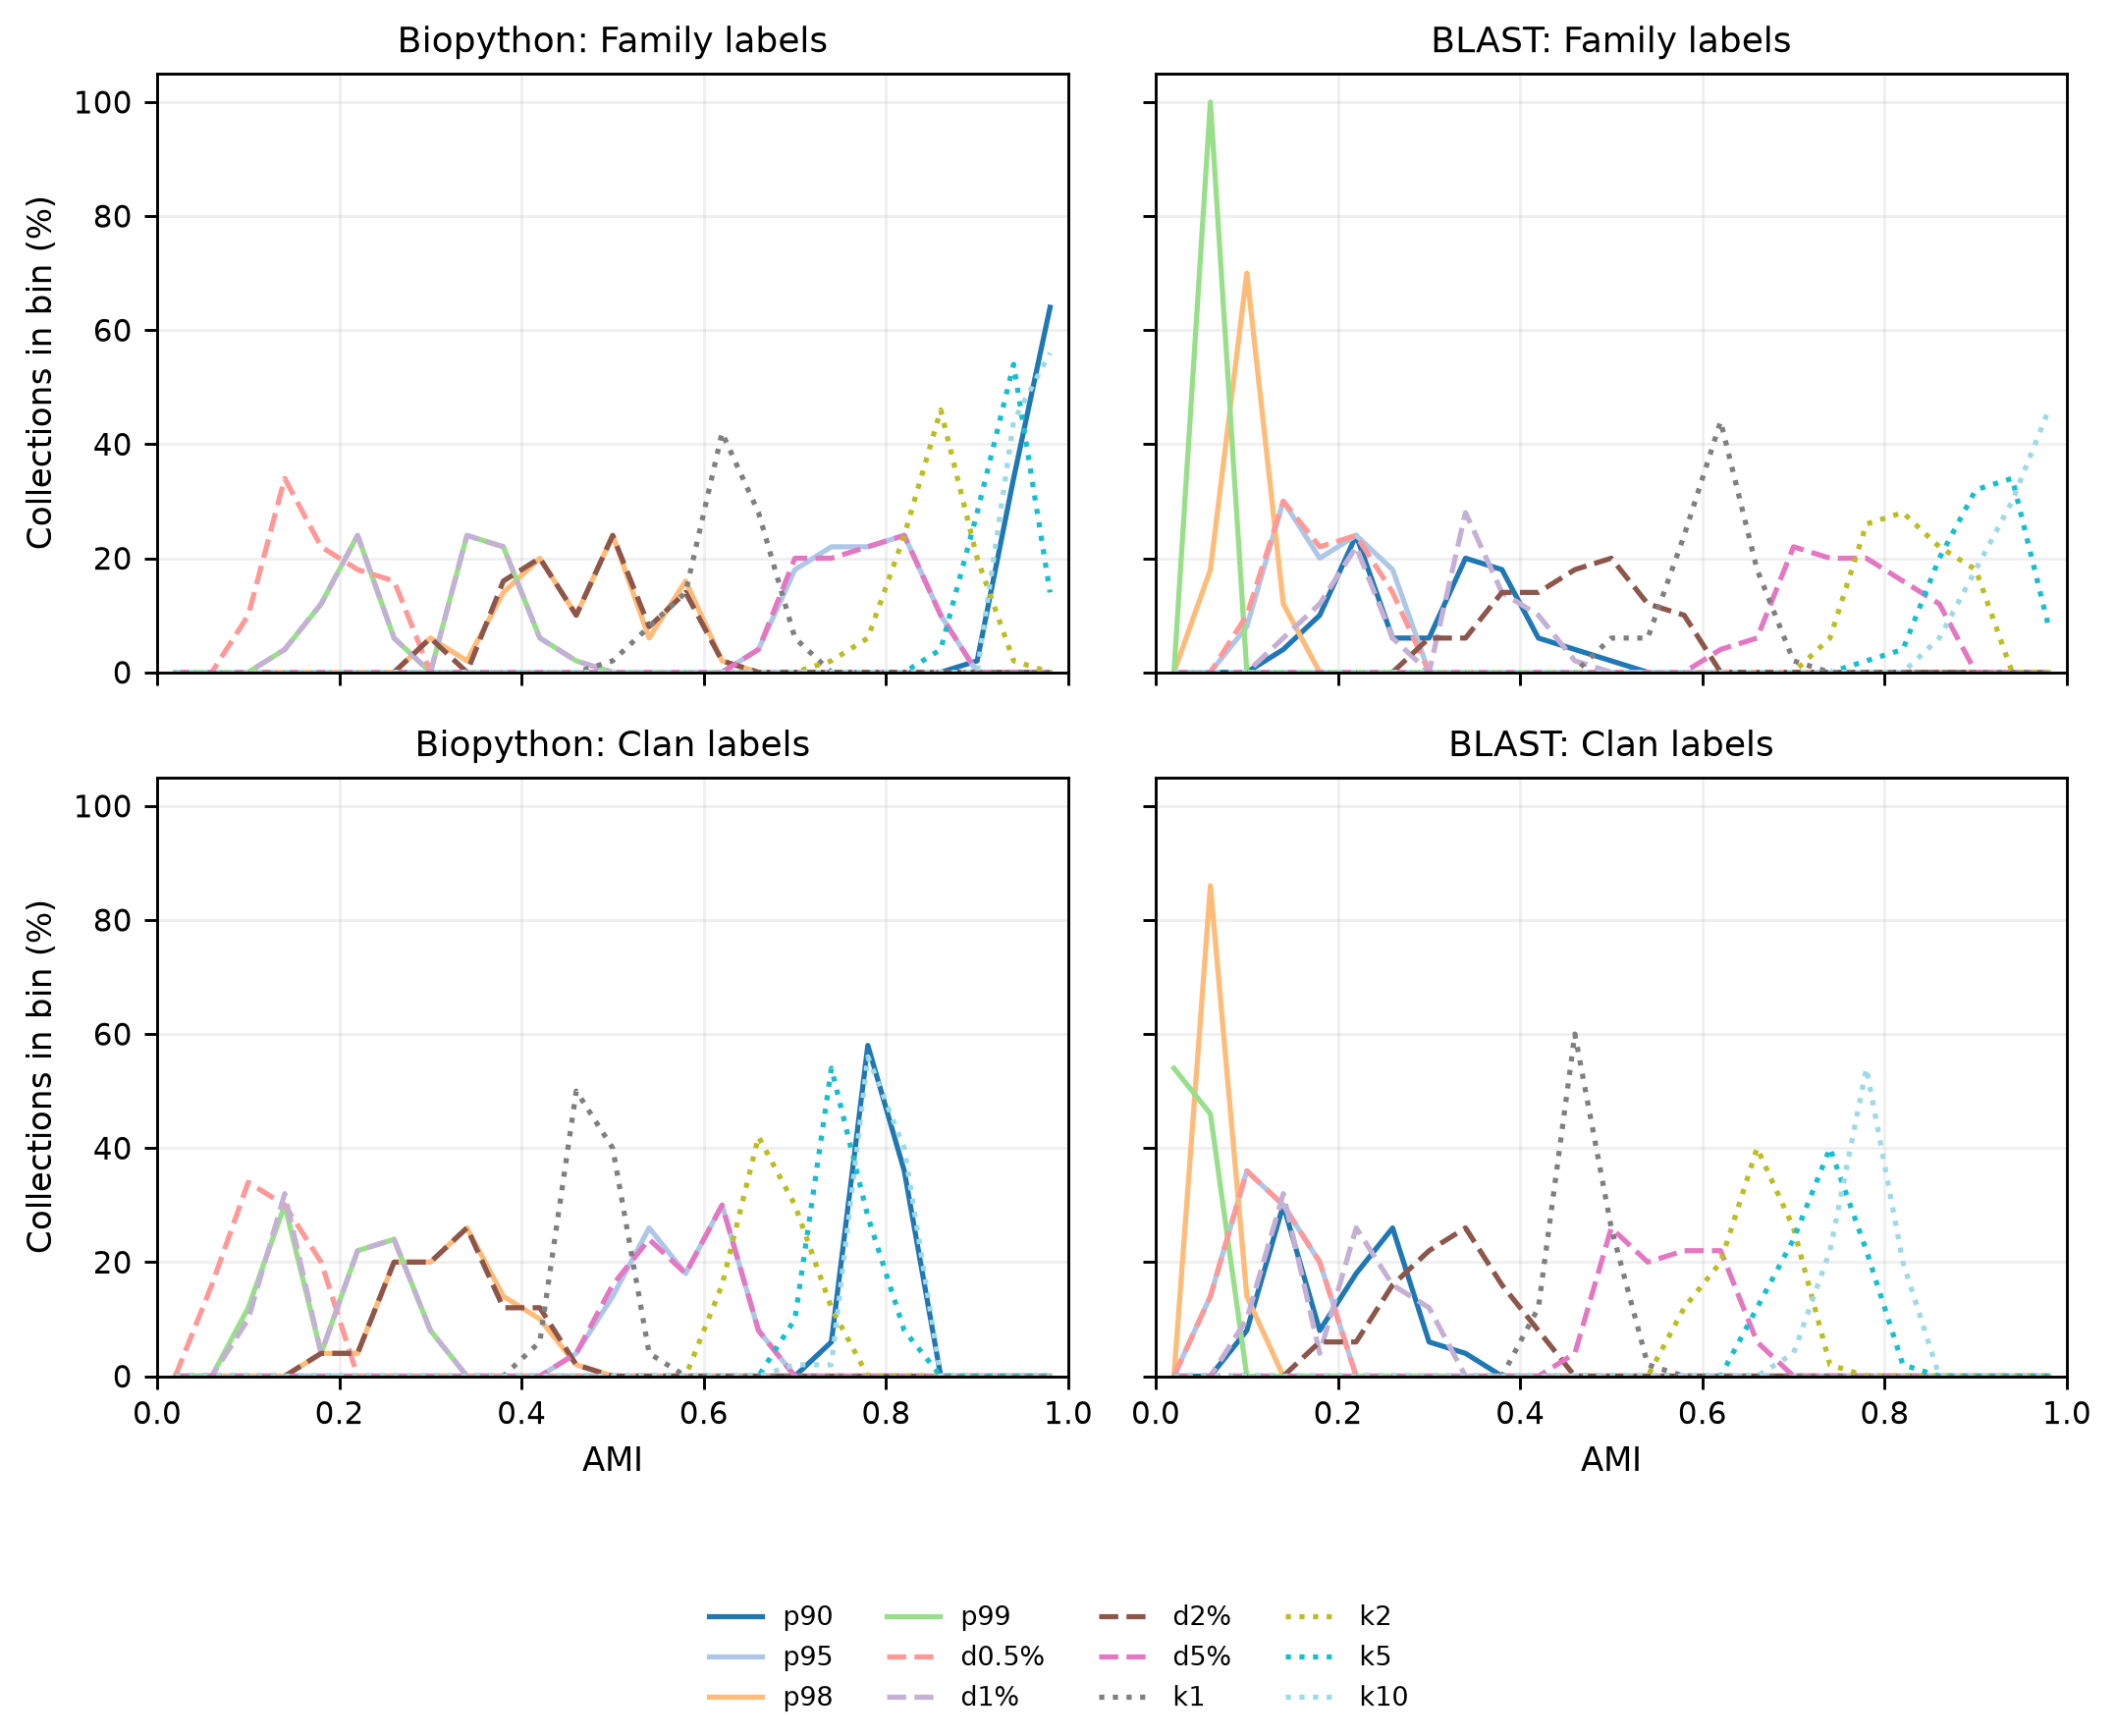

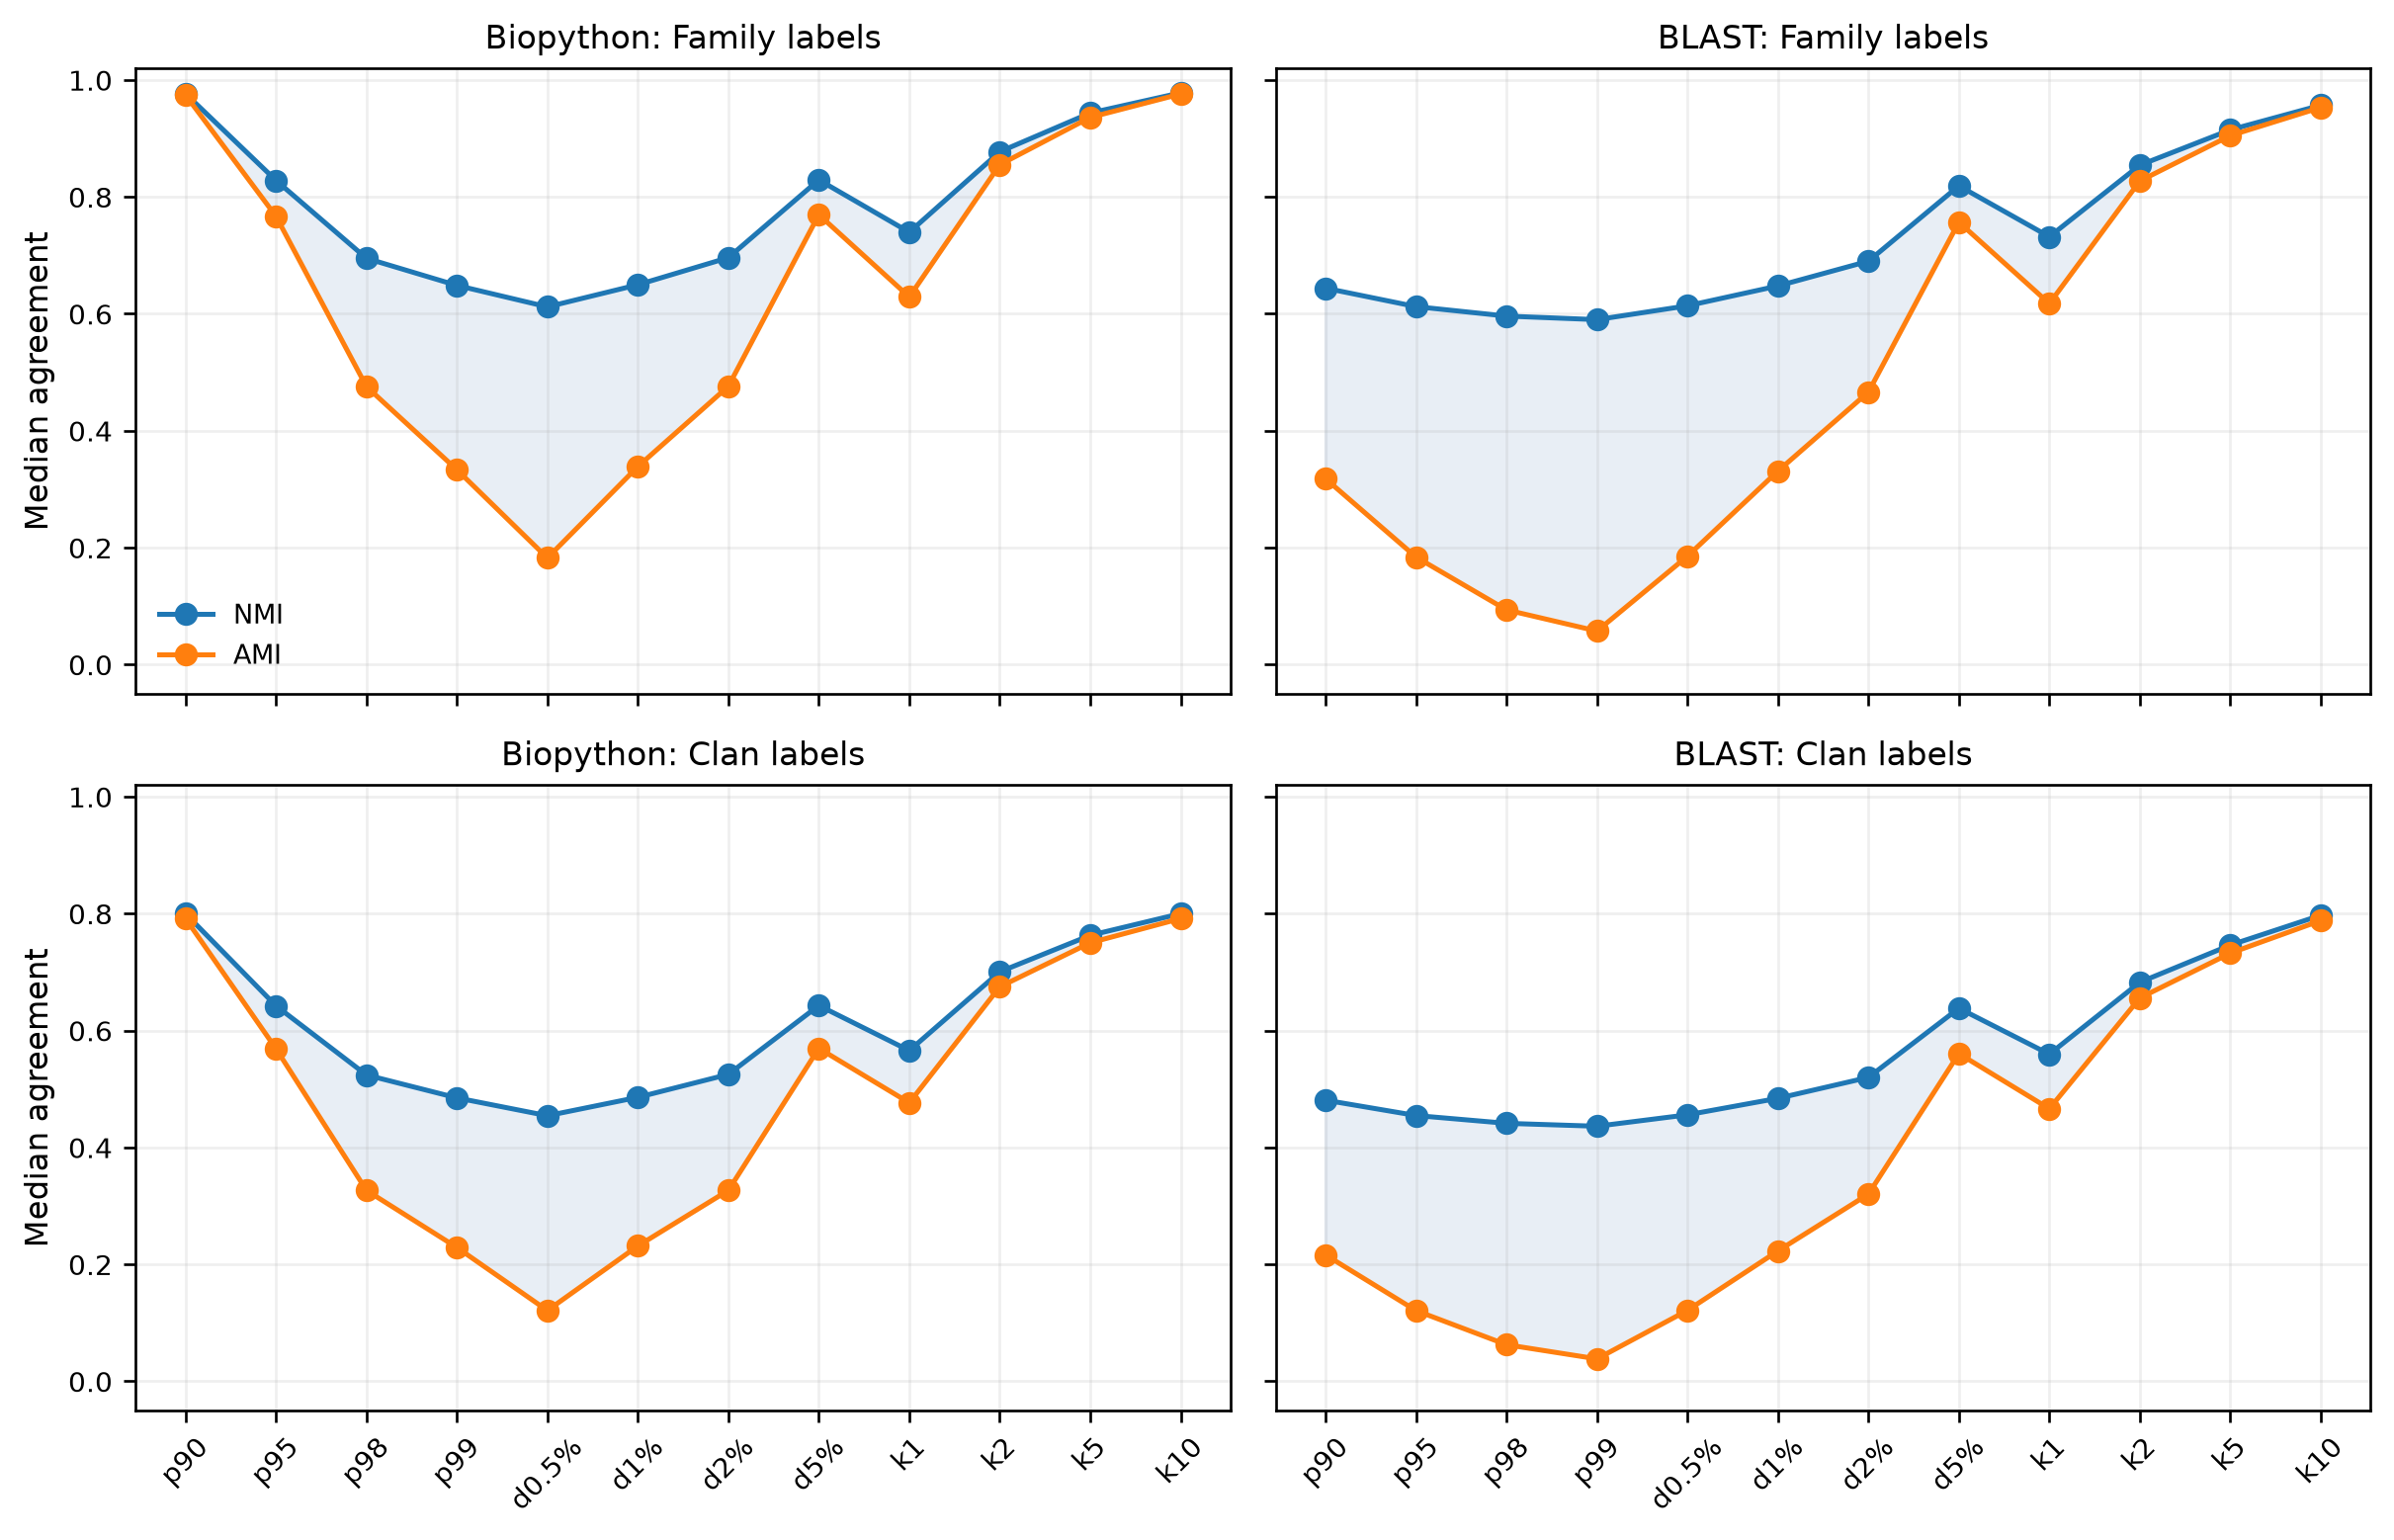

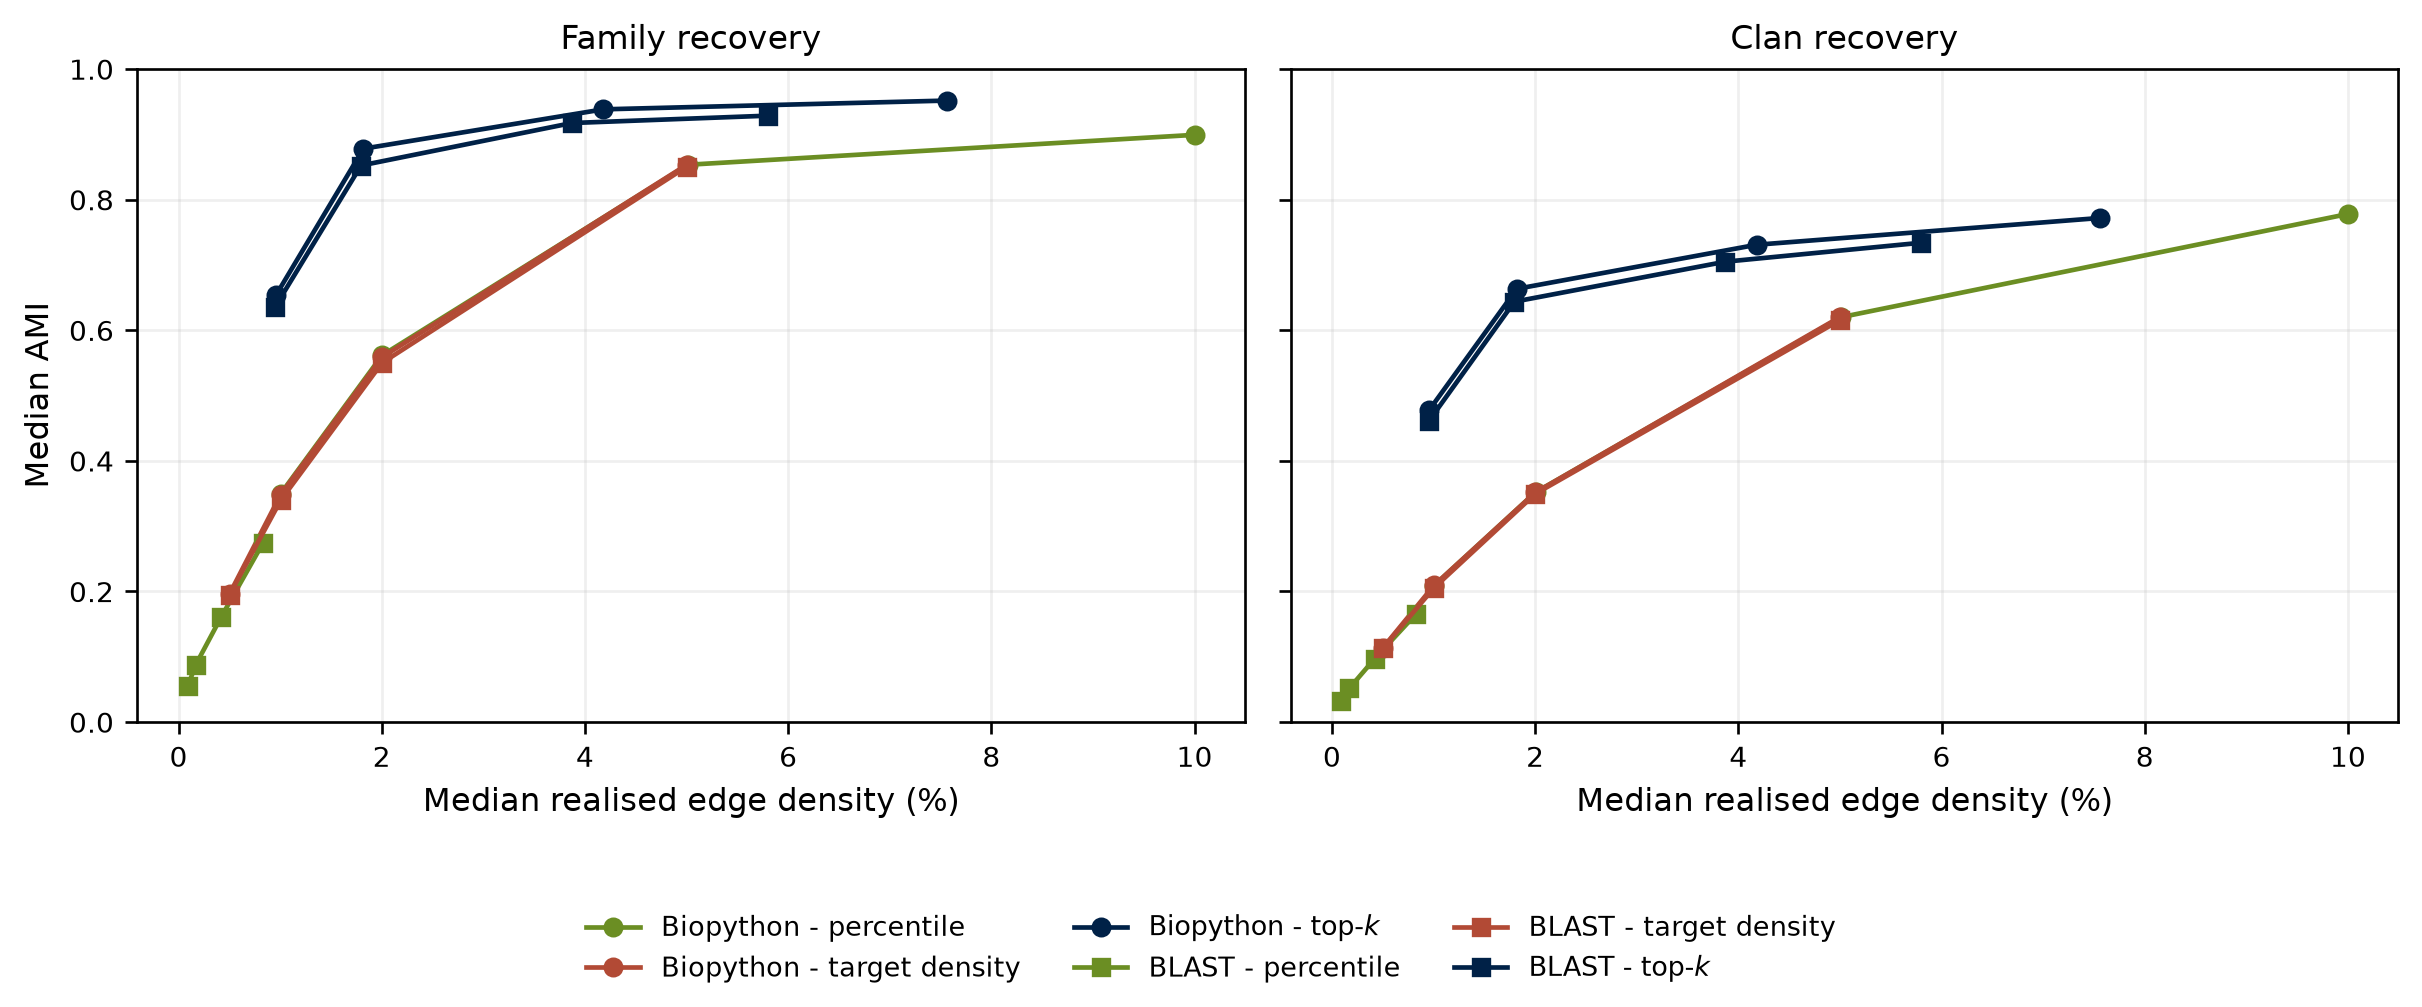

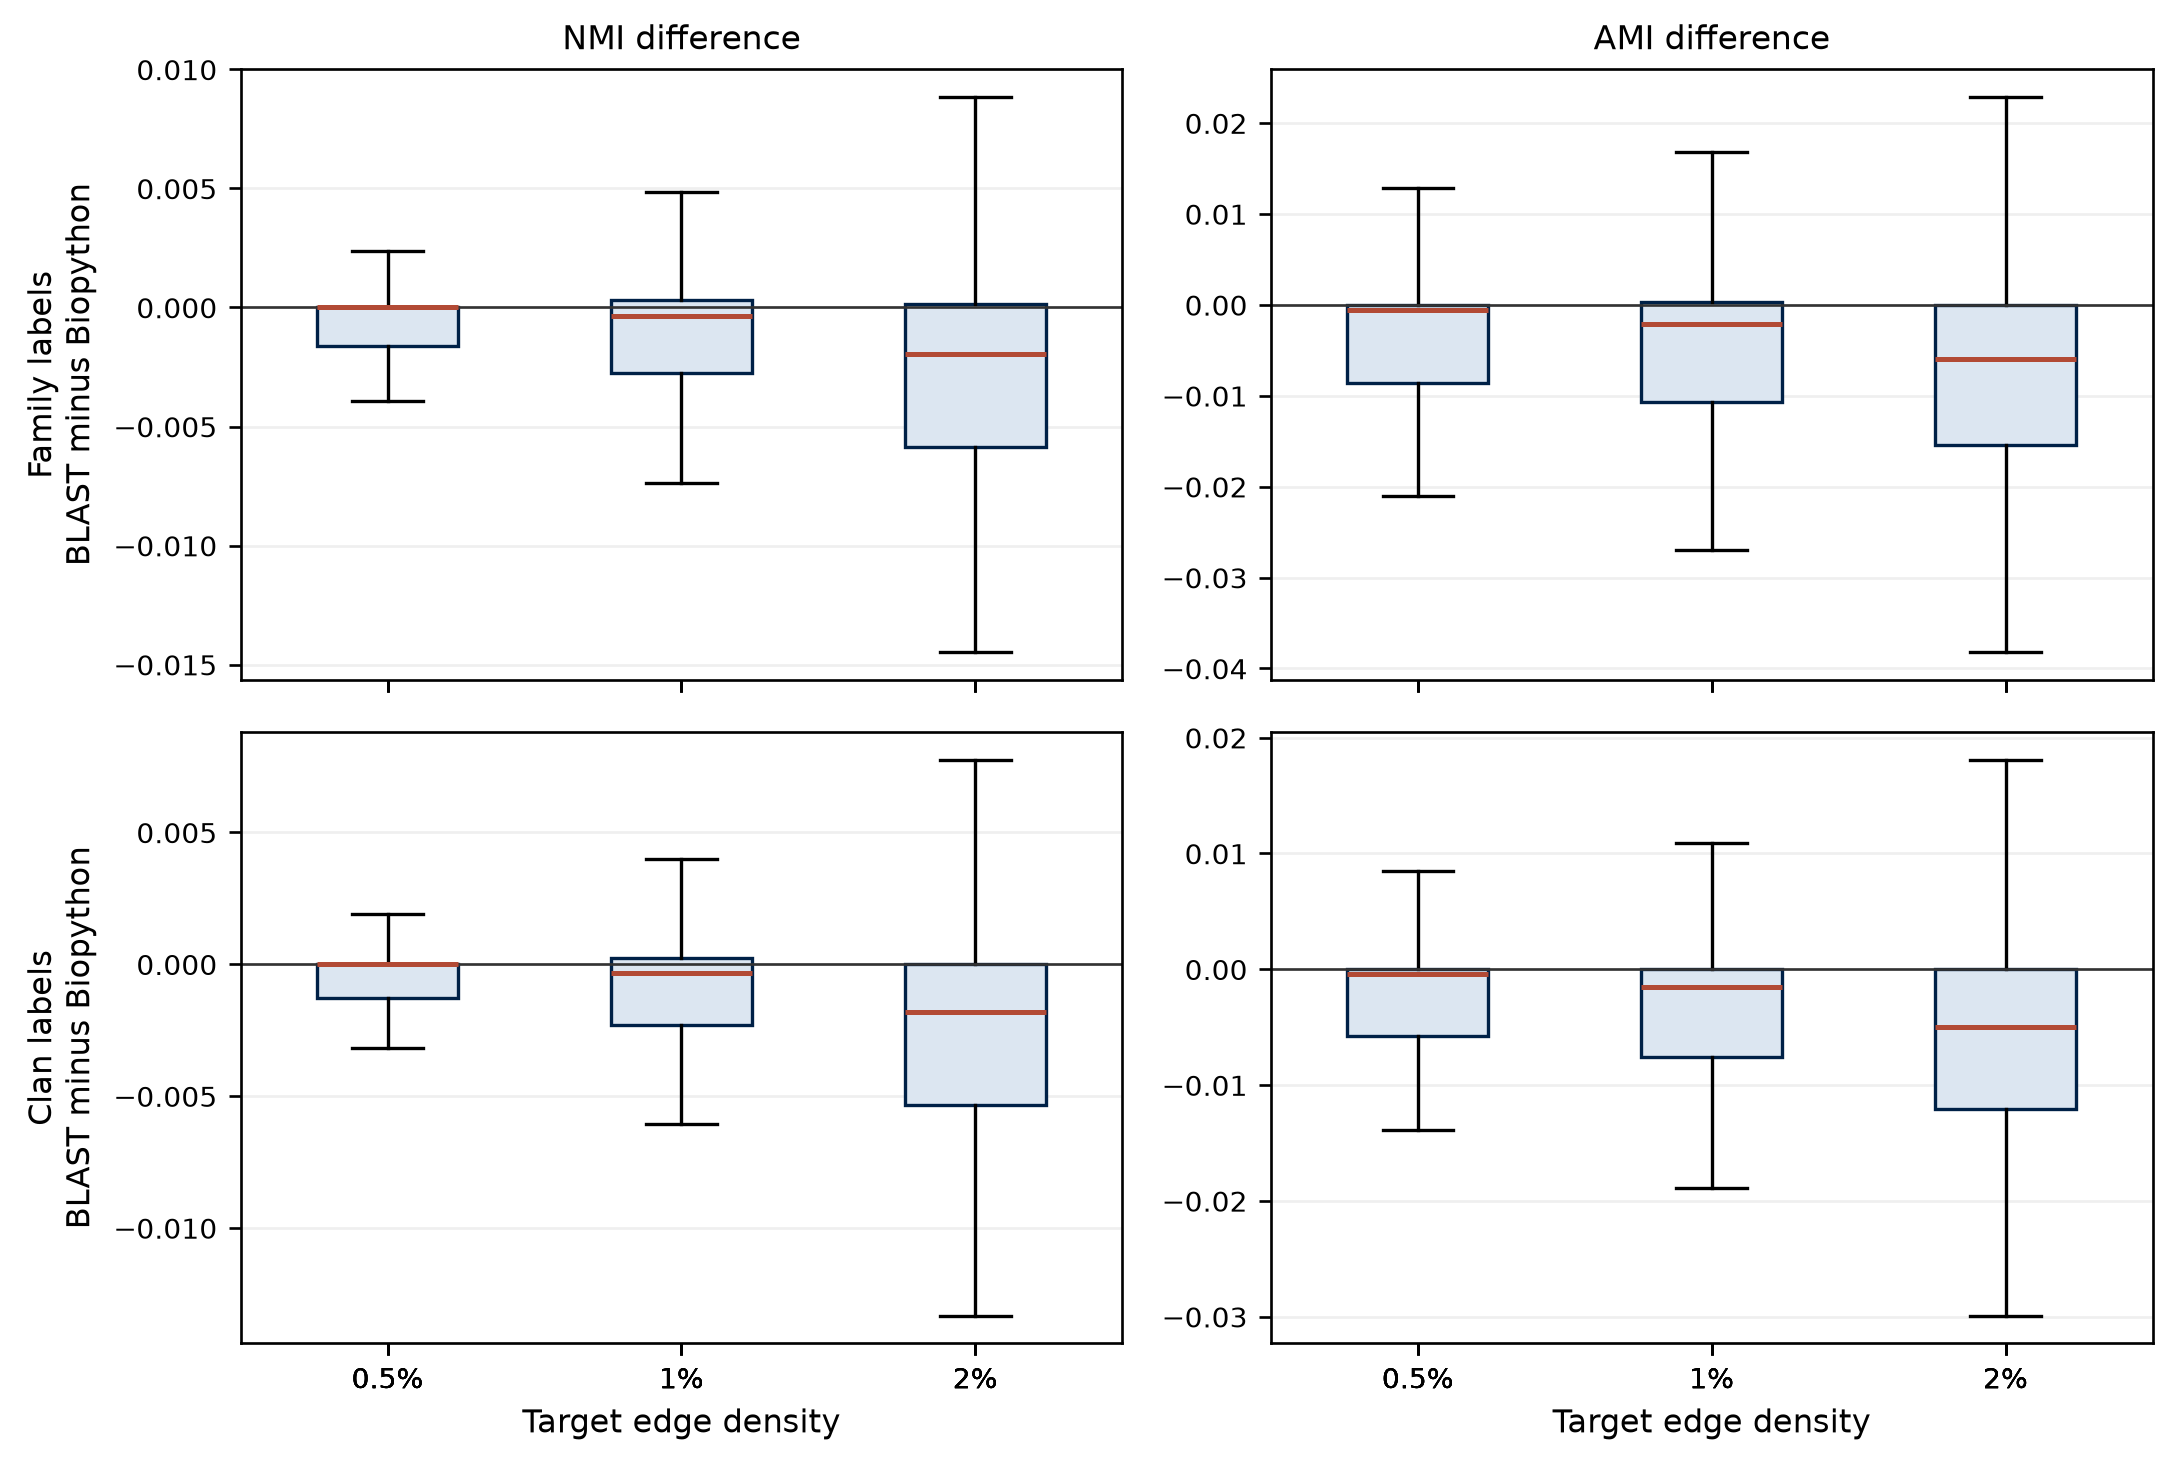

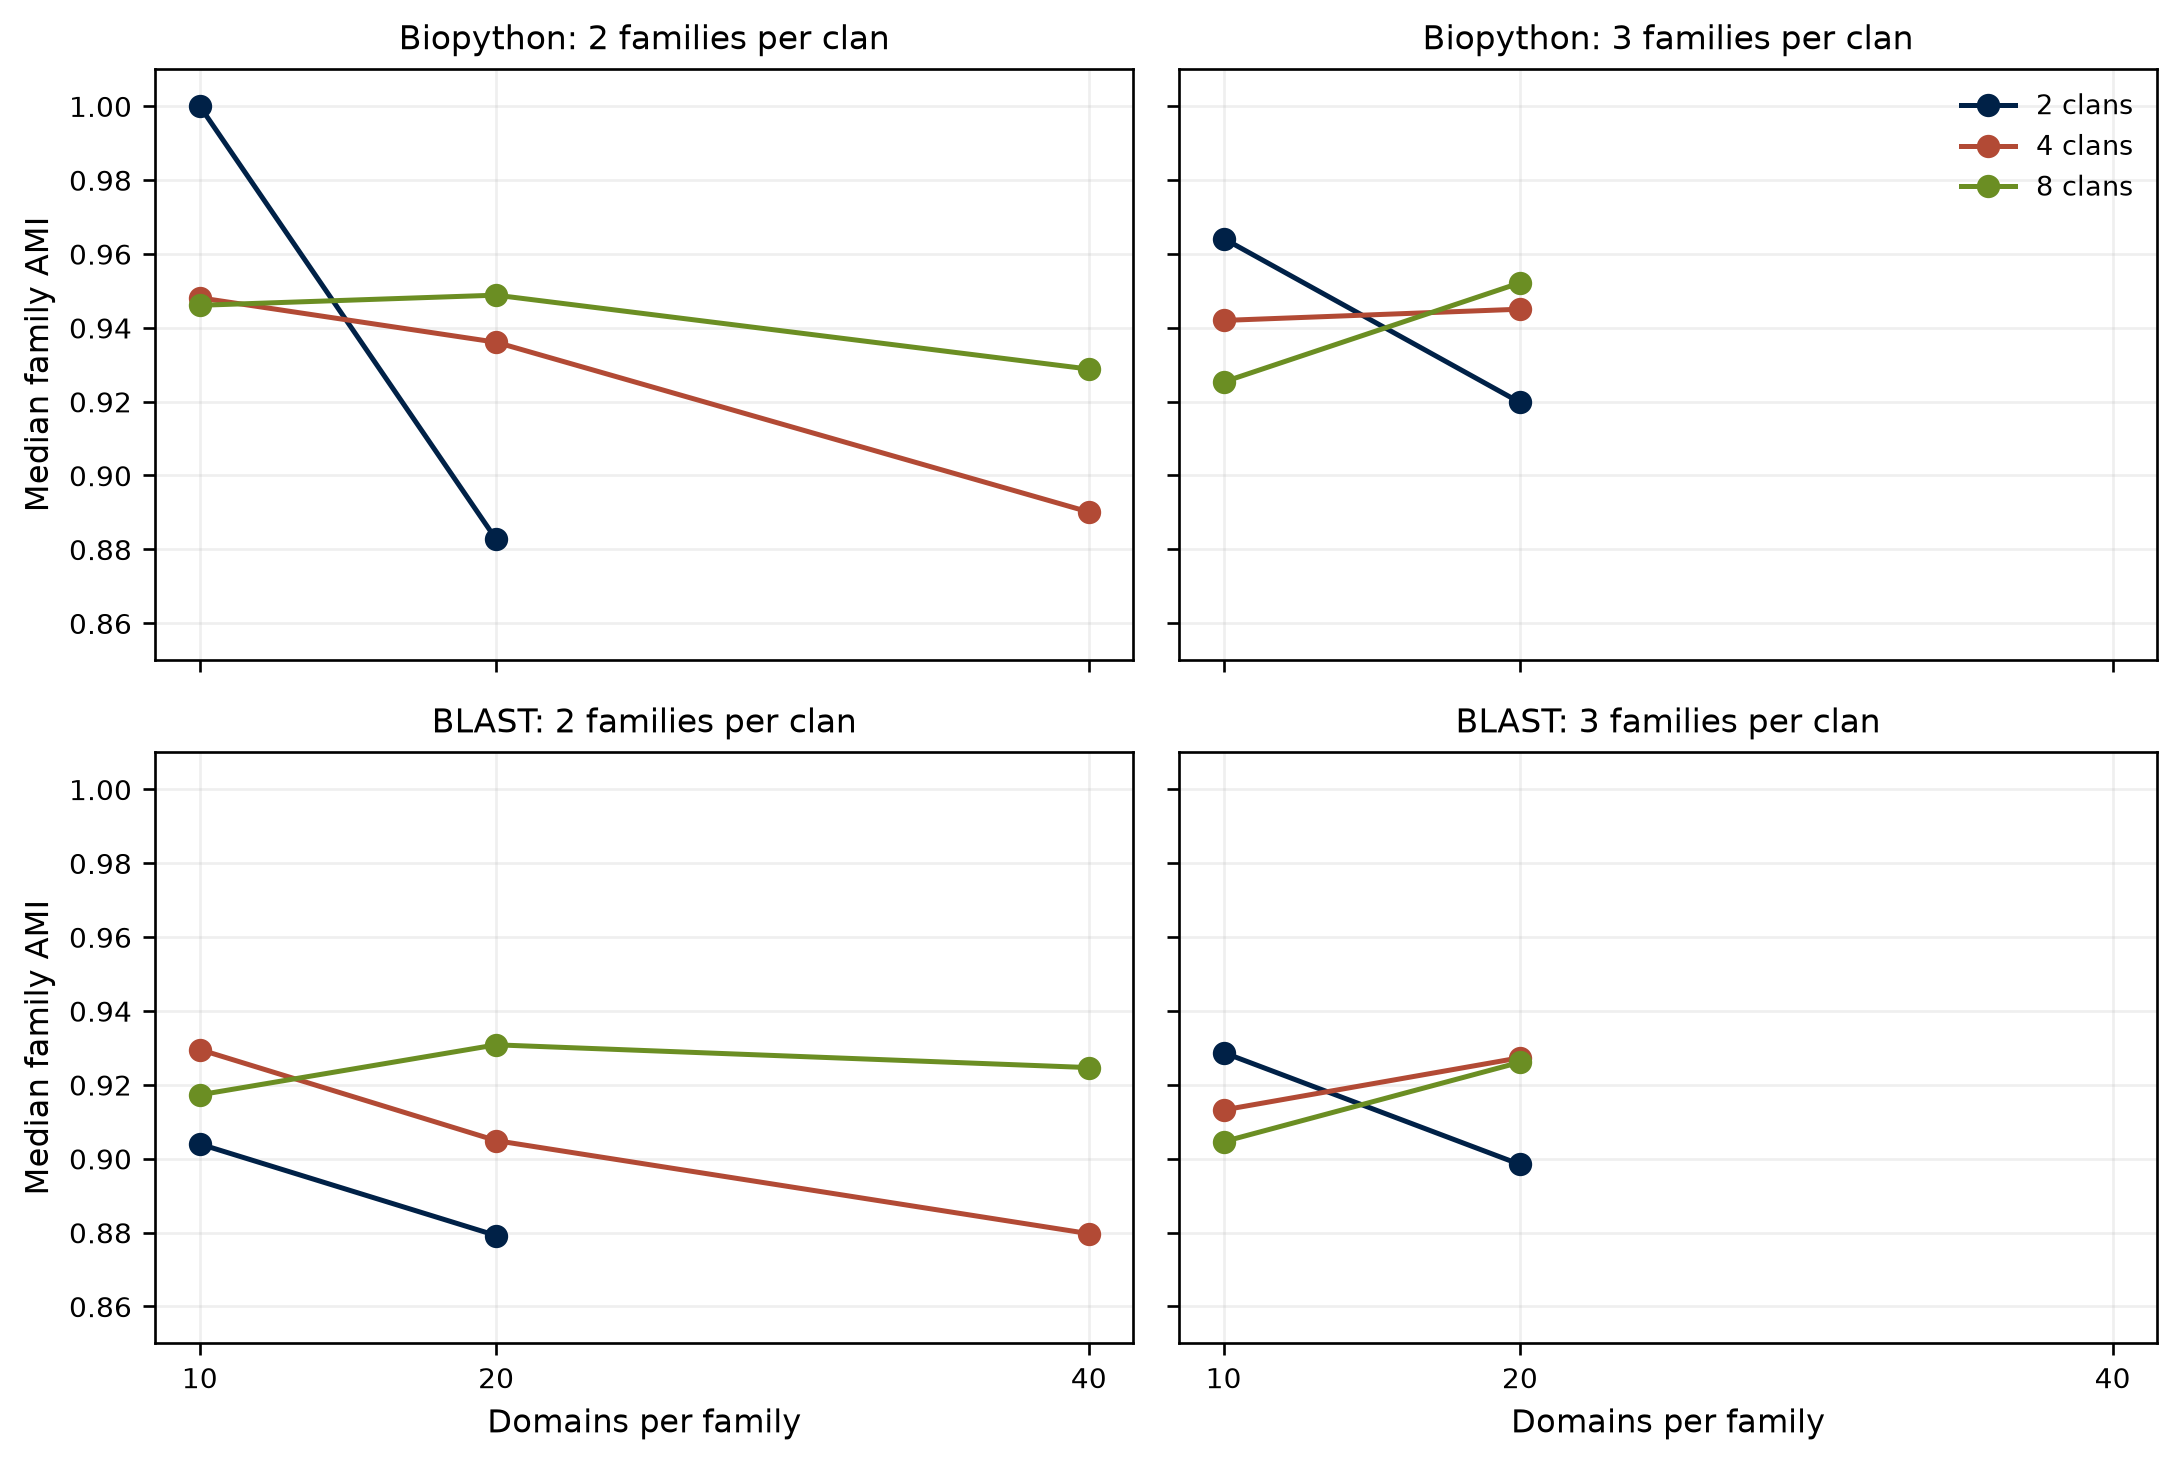

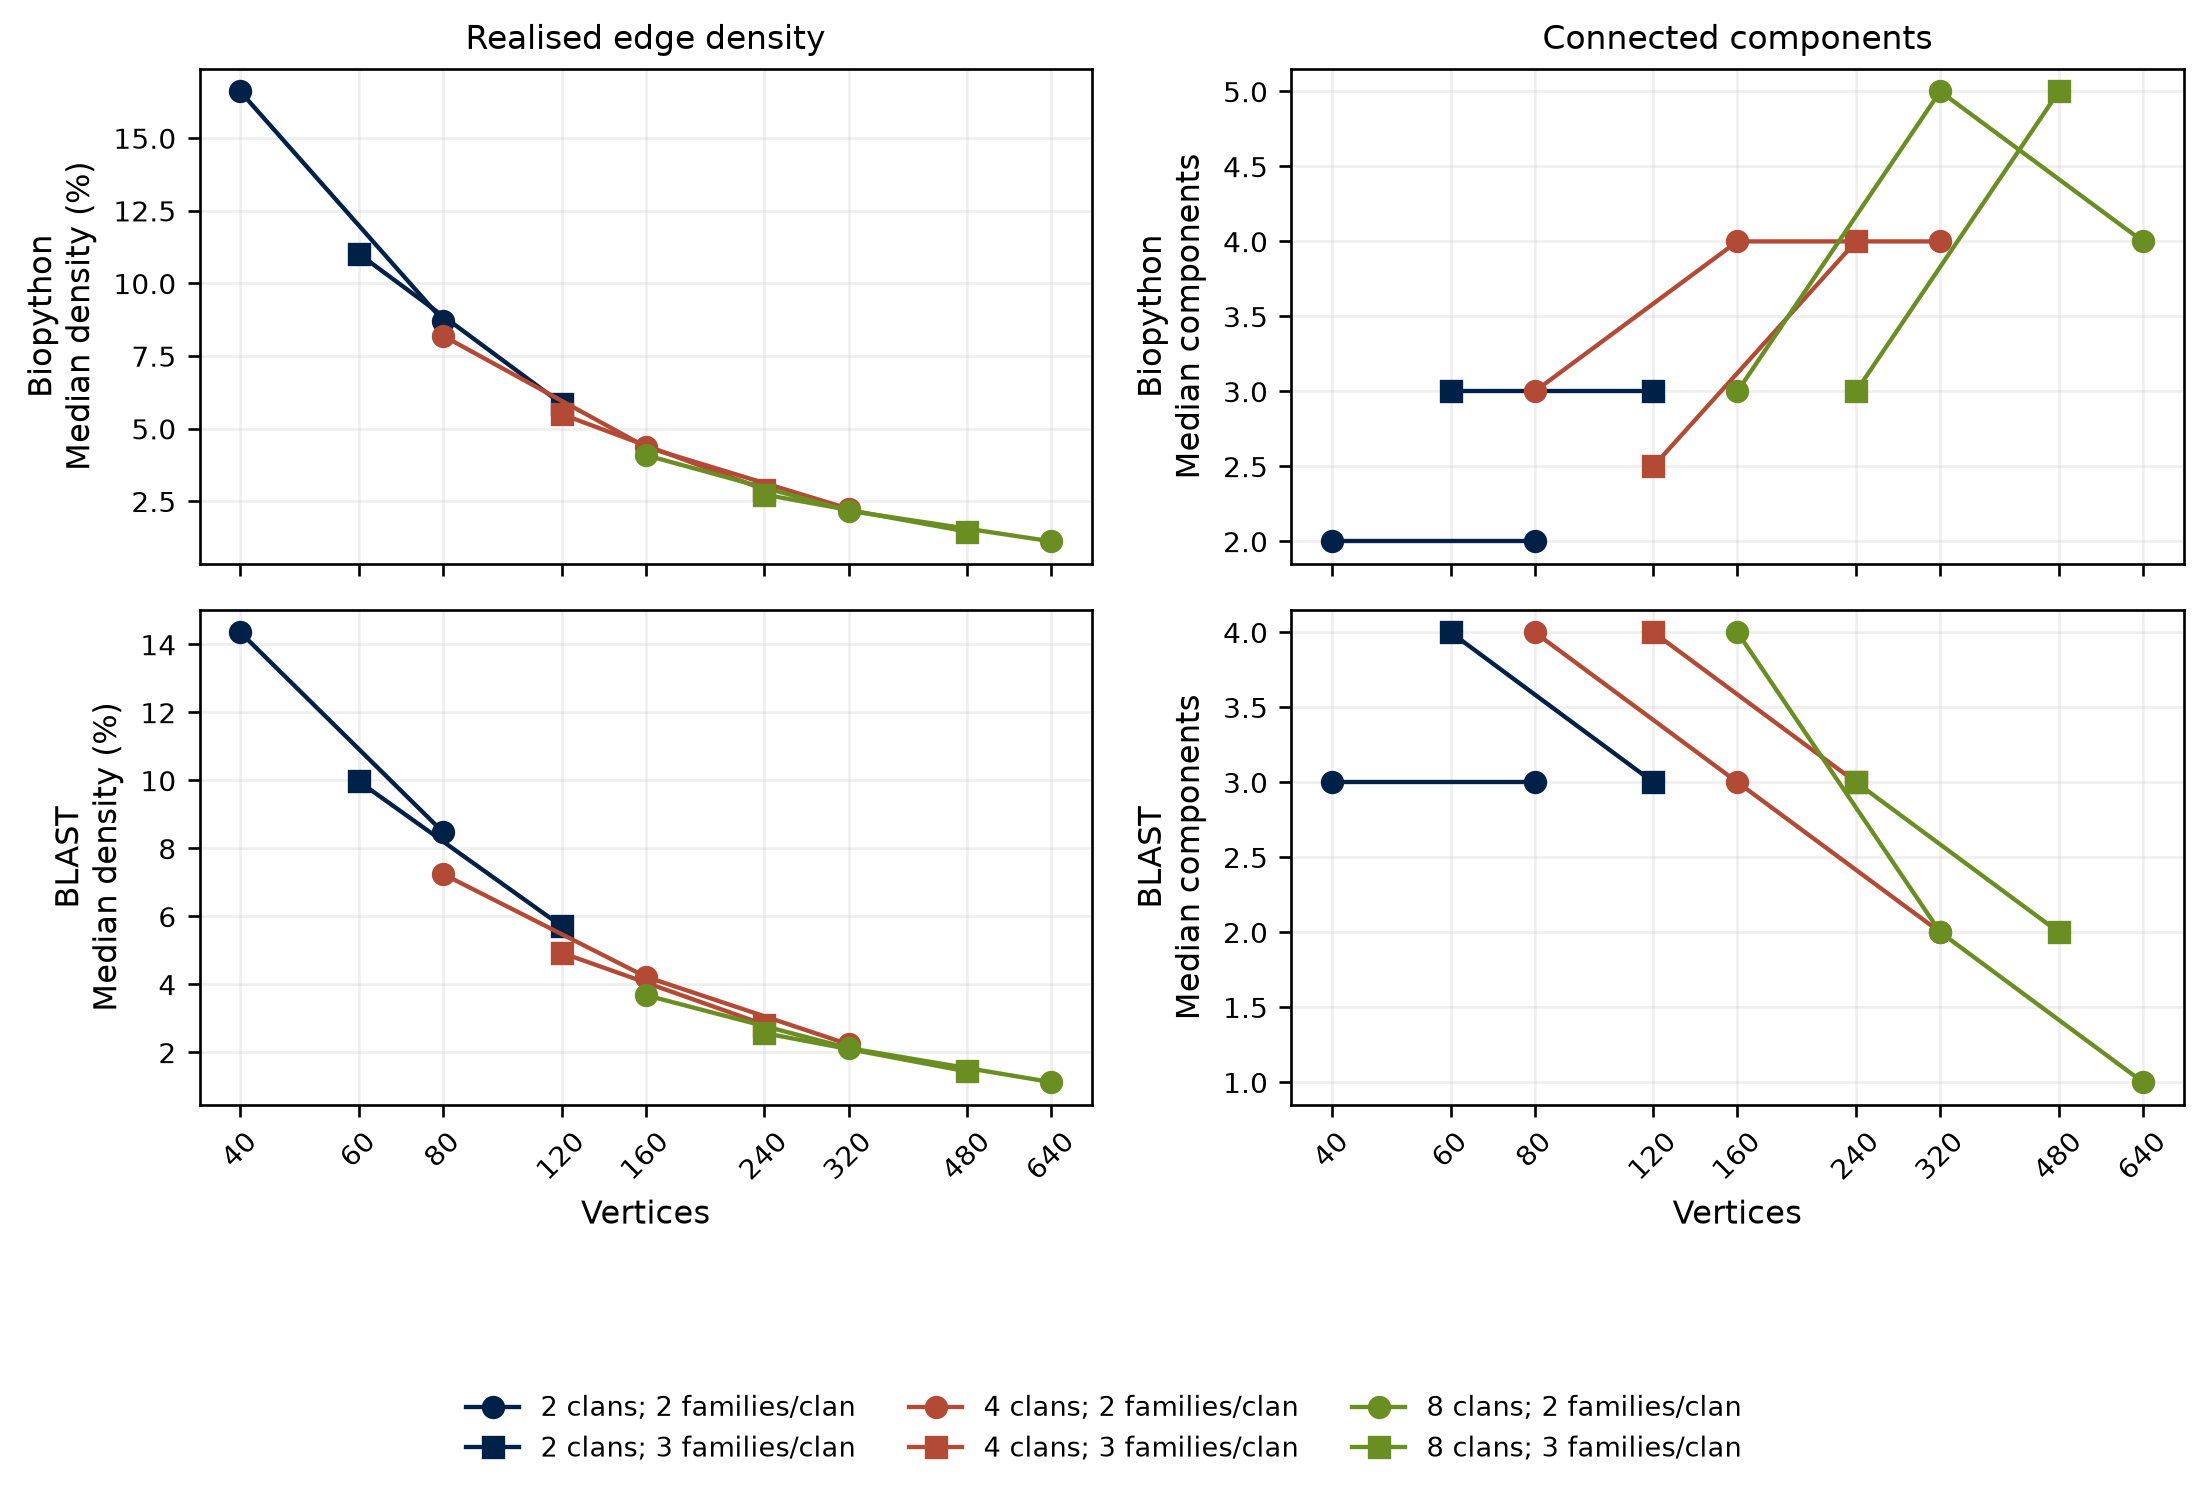

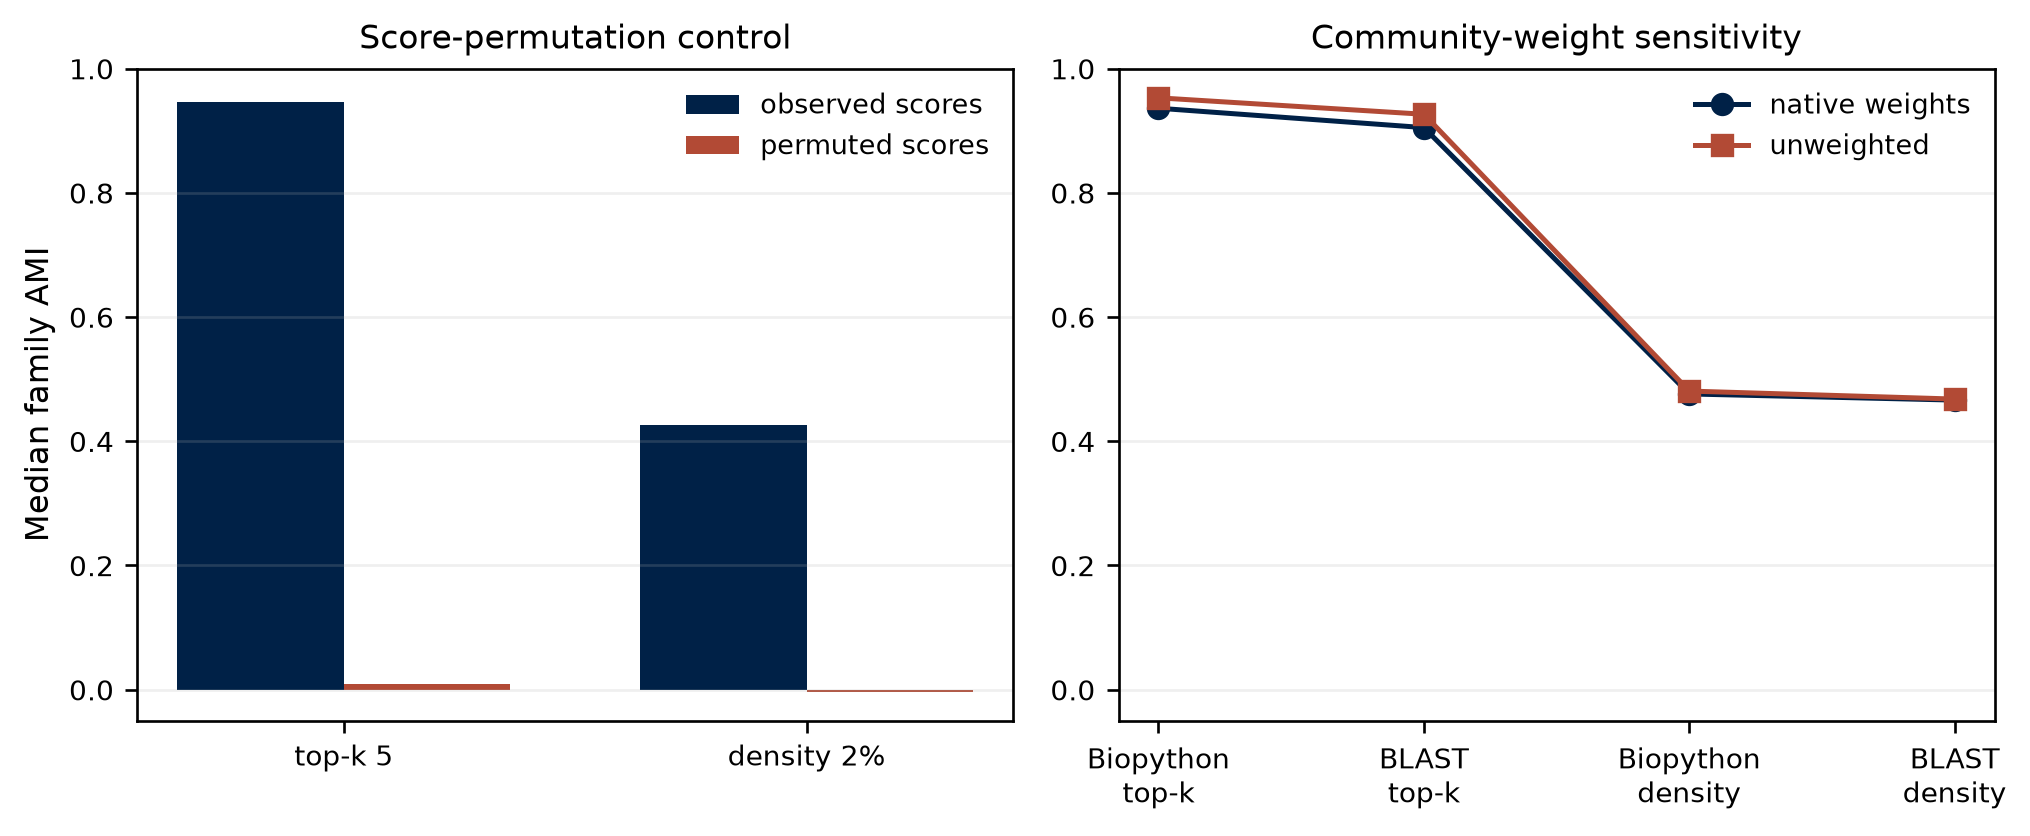

,reference_label,threshold_rule,threshold,score_treatment,collections,median_nmi,median_ami,median_communities
0,clan_accession,target_density,0.02,observed pair scores,20,0.505892,0.293941,90.5
1,clan_accession,target_density,0.02,scores permuted among pairs,20,0.085654,-0.001302,18.0
2,clan_accession,top_k,5.00,observed pair scores,20,0.762036,0.749299,10.0
3,clan_accession,top_k,5.00,scores permuted among pairs,20,0.056863,0.002694,10.5
4,family_accession,target_density,0.02,observed pair scores,20,0.673641,0.425391,90.5
5,family_accession,target_density,0.02,scores permuted among pairs,20,0.163112,-0.003715,18.0
6,family_accession,top_k,5.00,observed pair scores,20,0.952294,0.946619,10.0
7,family_accession,top_k,5.00,scores permuted among pairs,20,0.123954,0.009322,10.5


In [20]:
report_asset_run = subprocess.run(
    [sys.executable, str(PROJECT_ROOT / 'scripts/build_report_assets.py')],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    check=True,
)
print(report_asset_run.stdout.strip())

REPORT_FIGURE_DIRECTORY = PROJECT_ROOT / 'outputs/figures/pfam_large_panel_report'
for filename in [
    'representative_graphs.png',
    'score_method_comparison.png',
    'percentile_density_mismatch.png',
    'rule_topology.png',
    'rule_nmi_frequency.png',
    'rule_ami_frequency.png',
    'metric_comparison.png',
    'rule_recovery.png',
    'matched_density_differences.png',
    'composition_recovery.png',
    'composition_topology.png',
    'sensitivity_checks.png',
]:
    display(Image(filename=REPORT_FIGURE_DIRECTORY / filename))

NULL_DIRECTORY = PROJECT_ROOT / 'outputs/tables/pfam_large_panel_score_permutation_null'
null_results = pd.read_csv(NULL_DIRECTORY / 'graph_recovery_results.tsv', sep='	')
null_manifest = json.loads((NULL_DIRECTORY / 'run_manifest.json').read_text())
null_collection_ids = set(null_results['collection_id'])
real_for_null = primary_results.loc[
    (primary_results['collection_id'].isin(null_collection_ids))
    & (primary_results['method'] == null_manifest['method'])
    & (
        ((primary_results['threshold_rule'] == 'top_k') & (primary_results['threshold'] == 5))
        | (
            (primary_results['threshold_rule'] == 'target_density')
            & (primary_results['threshold'] == 0.02)
        )
    )
].assign(score_treatment='observed pair scores')
null_comparison = pd.concat(
    [
        real_for_null,
        null_results.assign(score_treatment='scores permuted among pairs'),
    ],
    ignore_index=True,
)
display(
    null_comparison.groupby(
        ['reference_label', 'threshold_rule', 'threshold', 'score_treatment'],
        as_index=False,
    ).agg(
        collections=('collection_id', 'nunique'),
        median_nmi=('nmi', 'median'),
        median_ami=('ami', 'median'),
        median_communities=('inferred_community_count', 'median'),
    )
)


In [21]:
# Derive a compact, traceable results table from the artifacts loaded above.
family_effects = effect_summary.loc[
    effect_summary["factor varied"].isin(
        [
            "graph setting (rule + parameter)",
            "collection composition",
            "alignment method | top_k only",
            "alignment method | percentile only",
            "alignment method | target_density only",
        ]
    )
]
fully_matched_family = paired_method_summary.loc[
    (paired_method_summary["reference_label"] == "family_accession")
    & (paired_method_summary["threshold_rule"] == "target_density")
    & (paired_method_summary["comparison_status"] == "primary_matched_edge_budget")
]
percentile_family = paired_method_summary.loc[
    (paired_method_summary["reference_label"] == "family_accession")
    & (paired_method_summary["threshold_rule"] == "percentile")
]

headline_results = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    "result": "Raw graphs evaluated",
                    "value": all_results["graph_id"].nunique(),
                    "source": "two graph_recovery_results.tsv files",
                },
                {
                    "result": "Primary graphs after uniqueness audit",
                    "value": primary_results["graph_id"].nunique(),
                    "source": "collection_uniqueness.tsv + raw result tables",
                },
                {
                    "result": "Primary sampled collections",
                    "value": len(primary_collection_ids),
                    "source": "collection_fingerprints.tsv",
                },
            ]
        ),
        family_effects.rename(
            columns={"factor varied": "result", "median spread": "value"}
        ).assign(
            result=lambda table: (
                "Median family-" + table["measure"] + " range: " + table["result"]
            ),
            source="B7 calculation from primary raw results",
        )[["result", "value", "source"]],
        fully_matched_family.assign(
            result=lambda table: (
                "Median absolute family-NMI method difference at density "
                + table["threshold"].astype(str)
            ),
            value=lambda table: table["median_absolute_nmi_difference"],
            source="paired_method_summary.tsv",
        )[["result", "value", "source"]],
        percentile_family.assign(
            result=lambda table: (
                "Median absolute family-NMI method difference at percentile "
                + table["threshold"].astype(str)
            ),
            value=lambda table: table["median_absolute_nmi_difference"],
            source="paired_method_summary.tsv",
        )[["result", "value", "source"]],
    ],
    ignore_index=True,
)
count_results = {
    'Raw graphs evaluated',
    'Primary graphs after uniqueness audit',
    'Primary sampled collections',
}
headline_display = headline_results.copy()
headline_display['value'] = [
    f'{int(value):,}' if result in count_results else f'{value:.4f}'
    for result, value in zip(headline_display['result'], headline_display['value'])
]
display(headline_display)


,result,value,source
0,Raw graphs evaluated,"21,600",two graph_recovery_results.tsv files
1,Primary graphs after uniqueness audit,"16,800",collection_uniqueness.tsv + raw result tables
2,Primary sampled collections,700,collection_fingerprints.tsv
3,Median family-NMI range: graph setting (rule +...,0.3252,B7 calculation from primary raw results
4,Median family-NMI range: collection composition,0.2468,B7 calculation from primary raw results
5,Median family-NMI range: alignment method | to...,0.0141,B7 calculation from primary raw results
6,Median family-NMI range: alignment method | pe...,0.1400,B7 calculation from primary raw results
7,Median family-NMI range: alignment method | ta...,0.0017,B7 calculation from primary raw results
8,Median family-AMI range: graph setting (rule +...,0.8588,B7 calculation from primary raw results
9,Median family-AMI range: collection composition,0.2409,B7 calculation from primary raw results


## Conclusions, scope, and provenance

Displayed tables and figures support these conclusions:

1. Observed graphs recover Pfam labels above score-permutation control.
2. Recovery varies across composition, rule, and parameter.
3. Equal percentiles create unequal method densities when coverage differs.
4. Matched edge budgets reduce Biopython–BLAST recovery differences.
5. Sparse fragmentation raises NMI relative to AMI; cross-composition analysis
   therefore uses AMI.
6. Unweighted sensitivity retains reference-setting recovery pattern.

Numerical support is loaded in preceding cells, including `headline_results`.

### Result map

| Stage | Stored artifact | Producing implementation |
|---|---|---|
| Family eligibility | `data/processed/pfam_sampling_frame/family_selection_trace.tsv` and `selection_manifest.json` | `scripts/select_pfam_family_panel.py` |
| Master panel | `data/processed/pfam_large_panel/pfam_large_panel_metadata.tsv`, FASTA, and manifest | `scripts/prepare_pfam_clan_panel.py` |
| Collections | `data/processed/pfam_large_panel/resampling/collection_manifest.tsv`, `collection_membership.tsv`, and `experiment_manifest.json` | `scripts/generate_pfam_collections.py`, `src/.../sampling.py` |
| Pair scores | `outputs/tables/pfam_large_panel_scores/paired_scores.tsv` and `run_manifest.json` | `scripts/run_pair_scores.py`, scoring modules under `src/` |
| Graph evaluations | `outputs/tables/pfam_large_panel_graph_recovery_full/graph_recovery_results.tsv` and target-density counterpart | `scripts/run_resampled_graph_experiment.py`, `src/.../graphs.py`, `src/.../evaluation.py` |
| Unweighted sensitivity | `outputs/tables/pfam_large_panel_graph_recovery_unweighted_reference/` | `scripts/run_resampled_graph_experiment.py --unweighted-communities` |
| Permutation control | `outputs/tables/pfam_large_panel_score_permutation_null/` | `scripts/run_score_permutation_null.py` |
| Audits and summaries | `outputs/tables/pfam_large_panel_graph_summary/*.tsv` and `summary_manifest.json` | `scripts/summarize_resampled_graph_experiment.py` |
| Report figures | `outputs/figures/pfam_large_panel_report/*.png` and `report/figure_provenance.tsv` | `scripts/build_report_assets.py` |

JSON manifests record parameters, versions, timestamps, checksums, and
producer. Raw graph tables determine summaries and figures.

### Scope

- Nodes: curated Pfam seed-domain instances; full-length proteins lie outside
  study scope.
- Scaled methods: Biopython and BLAST; DEDAL appears in pilot.
- Master panel: diversity-selected domains from 24 families and eight clans;
  natural-prevalence estimation lies outside design.
- Primary distributions: conditions with 50 distinct node sets; saturated
  conditions remain in audit tables.
- Matched-method inference: target densities with zero coverage shortfall.
- Community model: weighted Louvain at resolution 1; limited stochasticity and
  resolution analysis.

Future work includes broader Pfam panels, full-length proteins, synthetic
known-tree data, hierarchical uncertainty, filtration-based graph analysis,
and alternative community algorithms.

## References

Canonical records: `references/references.bib`.

- Local alignment and scores: `smith1981identification`,
  `gotoh1982improved`, `henikoff1992amino`, `karlin1990methods`,
  `altschul1990basic`.
- Software and models: `cock2009biopython`, `camacho2009blastplus`,
  `llinareslopez2023deep`, `hagberg2008exploring`.
- Pfam and SSNs: `mistry2021pfam`, `atkinson2009sequence`, `gerlt2015efi`,
  `apeltsin2011threshold`, `hornung2023objective`.
- Communities and agreement: `blondel2008fast`, `vinh2010information`,
  `pedregosa2011scikitlearn`.
